In [ ]:
from google.colab import drive
drive.mount('/content/drive')

!pip install -q timm torch torchvision scikit-learn pandas matplotlib seaborn pillow

Mounted at /content/drive


In [ ]:
import os
import shutil
import random
import time
import copy
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from PIL import Image, ImageFilter, ImageChops, ImageEnhance
from tqdm import tqdm
from collections import defaultdict

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, ConcatDataset
from torchvision import datasets, transforms

import timm

from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import seaborn as sns

In [ ]:
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


In [ ]:



PROJECT_DIR     = "/content/drive/MyDrive/Thesis Student/P3 /Group_3_Spring_2025/Update dataset"


AUG_DIR         = os.path.join(PROJECT_DIR, "augmented_400_100_100_v2")
AUG_TRAIN_DIR   = os.path.join(AUG_DIR,     "train")
AUG_VAL_DIR     = os.path.join(AUG_DIR,     "val")
AUG_TEST_DIR    = os.path.join(AUG_DIR,     "test")

RESULTS_DIR     = os.path.join(PROJECT_DIR, "results")

os.makedirs(PROJECT_DIR, exist_ok=True)
os.makedirs(RESULTS_DIR, exist_ok=True)

print("Project folder :", PROJECT_DIR)
print("Aug dir        :", AUG_DIR)
print("Results dir    :", RESULTS_DIR)

Project folder : /content/drive/MyDrive/Thesis Student/P3 /Group_3_Spring_2025/Update dataset
Aug dir        : /content/drive/MyDrive/Thesis Student/P3 /Group_3_Spring_2025/Update dataset/augmented_400_100_100_v2
Results dir    : /content/drive/MyDrive/Thesis Student/P3 /Group_3_Spring_2025/Update dataset/results


In [ ]:
IMG_SIZE   = 224
BATCH_SIZE = 4
NUM_WORKERS = 2
EPOCHS     = 30
LR         = 1e-4

transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.1),
    transforms.RandomResizedCrop(
        IMG_SIZE,
        scale=(0.95, 1.0)   # zoom 0.05
    ),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

print("Transform ready.")
print(f"IMG_SIZE={IMG_SIZE}, BATCH_SIZE={BATCH_SIZE}, EPOCHS={EPOCHS}, LR={LR}")

Transform ready.
IMG_SIZE=224, BATCH_SIZE=4, EPOCHS=30, LR=0.0001


#efficientnet_b0= 0.7833

Classes          : ['anger', 'fear', 'joy', 'natural', 'sadness', 'surprise']
Number of classes: 6
Train images     : 2400
Validation images: 600
Test images      : 600
Total training images (train + val): 3000

Training EfficientNet-B0 | Batch Size: 4


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model.safetensors:   0%|          | 0.00/21.4M [00:00<?, ?B/s]


Model Parameter Summary:
  Total parameters    : 4,015,234
  Trainable parameters: 4,015,234


Epoch 1/30 Validation: 100%|██████████| 150/150 [00:02<00:00, 63.58it/s]


...

Epoch 28/30 | Train Loss: 0.3228 | Train Acc: 0.9750 | Val Loss: 0.3608 | Val Acc: 0.9717 | LR: 0.00002803 | Time: 30.3s


Epoch 29/30 Validation: 100%|██████████| 150/150 [00:02<00:00, 63.58it/s]


Epoch 29/30 | Train Loss: 0.3157 | Train Acc: 0.9783 | Val Loss: 0.3426 | Val Acc: 0.9783 | LR: 0.00002140 | Time: 30.3s


Epoch 30/30 Validation: 100%|██████████| 150/150 [00:02<00:00, 66.49it/s]


Epoch 30/30 | Train Loss: 0.3124 | Train Acc: 0.9757 | Val Loss: 0.3388 | Val Acc: 0.9733 | LR: 0.00001550 | Time: 30.0s


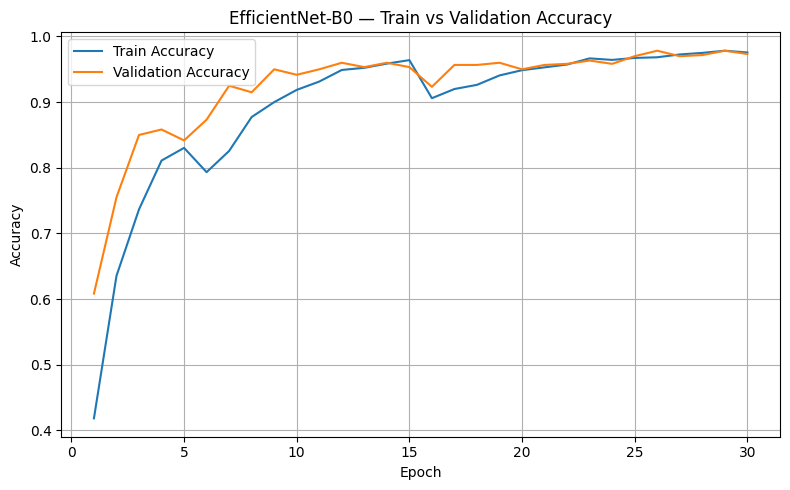

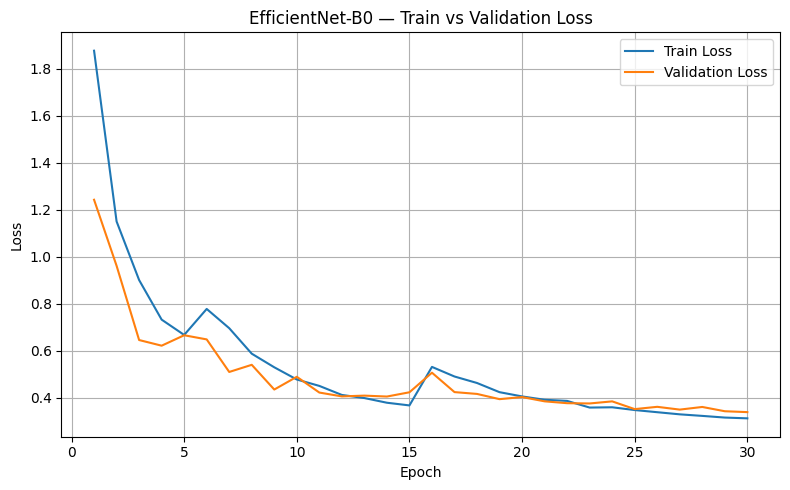

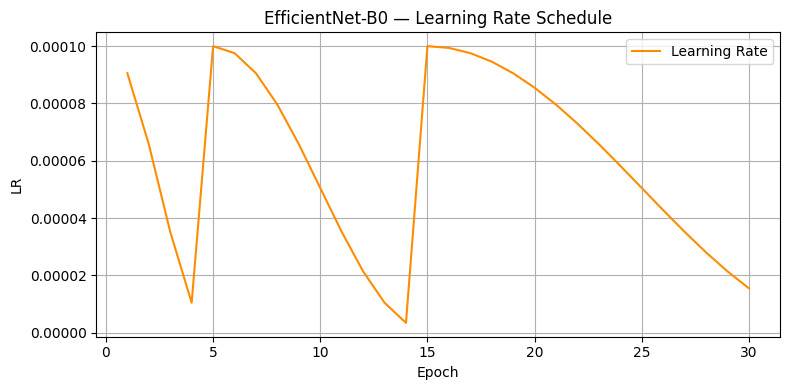


Final Testing on Test Set Only


Final Testing: 100%|██████████| 150/150 [03:54<00:00,  1.56s/it]



Final Test Classification Report:
              precision    recall  f1-score   support

       anger     0.7094    0.8300    0.7650       100
        fear     0.8440    0.9200    0.8804       100
         joy     0.8600    0.8600    0.8600       100
     natural     0.7946    0.8900    0.8396       100
     sadness     0.6515    0.4300    0.5181       100
    surprise     0.8021    0.7700    0.7857       100

    accuracy                         0.7833       600
   macro avg     0.7769    0.7833    0.7748       600
weighted avg     0.7769    0.7833    0.7748       600



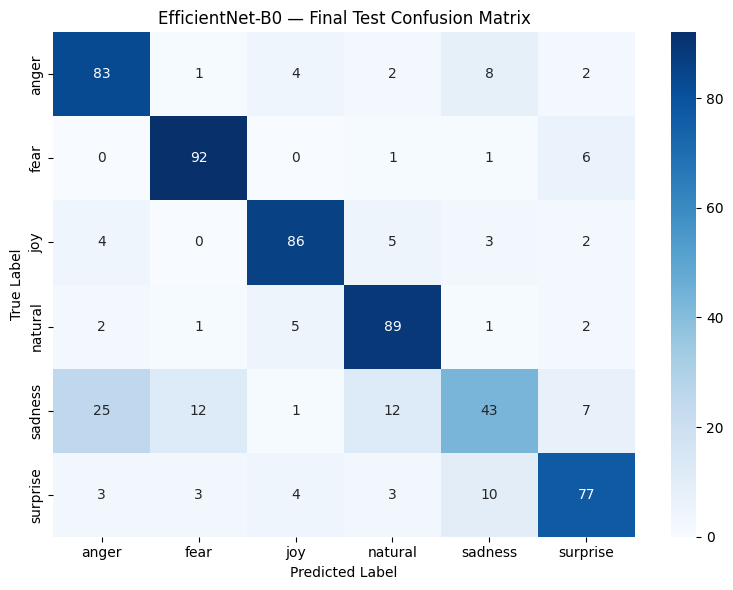


EfficientNet-B0 Final Result:


,model,batch_size,total_parameters,trainable_parameters,best_val_accuracy,final_test_accuracy,test_macro_precision,test_macro_recall,test_macro_f1,test_weighted_precision,test_weighted_recall,test_weighted_f1
0,efficientnet_b0,4,4015234,4015234,0.9783,0.7833,0.7769,0.7833,0.7748,0.7769,0.7833,0.7748



Best validation model saved to : /content/drive/MyDrive/Thesis Student/P3 /Group_3_Spring_2025/Update dataset/results/batch_16/efficientnet_b0/best_val_model.pth
All files saved inside         : /content/drive/MyDrive/Thesis Student/P3 /Group_3_Spring_2025/Update dataset/results/batch_16/efficientnet_b0


In [ ]:
import os
import time
import copy
import torch
import torch.nn as nn
import torch.optim as optim
import timm
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from torchvision import datasets
from torch.utils.data import DataLoader, ConcatDataset
from tqdm import tqdm
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# ============================================================
# Settings
# ============================================================

RESULTS_DIR_B16 = os.path.join(PROJECT_DIR, "results", "batch_4")
os.makedirs(RESULTS_DIR_B16, exist_ok=True)

# ============================================================
# Datasets — using already defined transform
# ============================================================

train_dataset = datasets.ImageFolder(AUG_TRAIN_DIR, transform=transform)
val_dataset   = datasets.ImageFolder(AUG_VAL_DIR,   transform=transform)
test_dataset  = datasets.ImageFolder(AUG_TEST_DIR,  transform=transform)

if train_dataset.classes != val_dataset.classes:
    raise ValueError("Train and validation class names do not match!")
if train_dataset.classes != test_dataset.classes:
    raise ValueError("Train and test class names do not match!")

class_names = train_dataset.classes
num_classes = len(class_names)

print("Classes          :", class_names)
print("Number of classes:", num_classes)
print("Train images     :", len(train_dataset))
print("Validation images:", len(val_dataset))
print("Test images      :", len(test_dataset))

combined_train_dataset = ConcatDataset([train_dataset, val_dataset])
print("Total training images (train + val):", len(combined_train_dataset))

train_loader = DataLoader(combined_train_dataset, batch_size=BATCH_SIZE, shuffle=True,  num_workers=NUM_WORKERS)
val_loader   = DataLoader(val_dataset,            batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)
test_loader  = DataLoader(test_dataset,           batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)

# ============================================================
# Helper — Parameter Count
# ============================================================

def count_parameters(model):
    total     = sum(p.numel() for p in model.parameters())
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f"  Total parameters    : {total:,}")
    print(f"  Trainable parameters: {trainable:,}")
    return total, trainable

# ============================================================
# Build Model
# ============================================================

def build_efficientnet_b0(num_classes):
    return timm.create_model("efficientnet_b0", pretrained=True, num_classes=num_classes)

# ============================================================
# Training Function
# ============================================================

def train_efficientnet_b0(epochs=EPOCHS, lr=LR, model_folder_name="efficientnet_b0"):
    print("\n" + "=" * 90)
    print("Training EfficientNet-B0 | Batch Size: 4")
    print("=" * 90)

    model_output_dir = os.path.join(RESULTS_DIR_B16, model_folder_name)
    os.makedirs(model_output_dir, exist_ok=True)

    model = build_efficientnet_b0(num_classes).to(device)

    # ── 1. Parameter summary ──────────────────────────────────
    print("\nModel Parameter Summary:")
    total_params, trainable_params = count_parameters(model)

    criterion = nn.CrossEntropyLoss(label_smoothing=0.05)
    optimizer = optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-4)
    scheduler = optim.lr_scheduler.CosineAnnealingWarmRestarts(optimizer, T_0=5, T_mult=2, eta_min=1e-6)

    # ── 2. Track best validation accuracy (not train) ─────────
    best_val_acc       = 0.0
    best_model_weights = copy.deepcopy(model.state_dict())
    best_val_path      = os.path.join(model_output_dir, "best_val_model.pth")

    history = {
        "train_loss": [], "train_acc": [],
        "val_loss":   [], "val_acc":   [],
        "lr":         []
    }

    for epoch in range(epochs):
        start_time = time.time()
        model.train()
        train_loss_sum, train_correct, train_total = 0.0, 0, 0

        for images, labels in tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs} Training"):
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(images)
            loss    = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            _, predictions  = torch.max(outputs, 1)
            train_loss_sum += loss.item() * images.size(0)
            train_correct  += torch.sum(predictions == labels).item()
            train_total    += labels.size(0)

        train_loss = train_loss_sum / train_total
        train_acc  = train_correct  / train_total

        model.eval()
        val_loss_sum, val_correct, val_total = 0.0, 0, 0

        with torch.no_grad():
            for images, labels in tqdm(val_loader, desc=f"Epoch {epoch+1}/{epochs} Validation"):
                images, labels = images.to(device), labels.to(device)
                outputs        = model(images)
                loss           = criterion(outputs, labels)
                _, predictions = torch.max(outputs, 1)
                val_loss_sum  += loss.item() * images.size(0)
                val_correct   += torch.sum(predictions == labels).item()
                val_total     += labels.size(0)

        val_loss = val_loss_sum / val_total
        val_acc  = val_correct  / val_total
        scheduler.step()

        current_lr = optimizer.param_groups[0]['lr']
        history["train_loss"].append(train_loss)
        history["train_acc"].append(train_acc)
        history["val_loss"].append(val_loss)
        history["val_acc"].append(val_acc)
        history["lr"].append(current_lr)

        # ── Save best validation weights ──────────────────────
        if val_acc > best_val_acc:
            best_val_acc       = val_acc
            best_model_weights = copy.deepcopy(model.state_dict())
            torch.save(model.state_dict(), best_val_path)
            saved_flag = "  ✓ best val saved"
        else:
            saved_flag = ""

        print(
            f"Epoch {epoch+1}/{epochs} | "
            f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f} | "
            f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f} | "
            f"LR: {current_lr:.8f} | "
            f"Time: {time.time()-start_time:.1f}s"
            f"{saved_flag}"
        )

    model.load_state_dict(best_model_weights)
    pd.DataFrame(history).to_csv(os.path.join(model_output_dir, "training_history.csv"), index=False)

    epochs_range = range(1, epochs + 1)

    # ── 3a. Accuracy curve ────────────────────────────────────
    plt.figure(figsize=(8, 5))
    plt.plot(epochs_range, history["train_acc"], label="Train Accuracy")
    plt.plot(epochs_range, history["val_acc"],   label="Validation Accuracy")
    plt.title("EfficientNet-B0 — Train vs Validation Accuracy")
    plt.xlabel("Epoch"); plt.ylabel("Accuracy"); plt.legend(); plt.grid(True); plt.tight_layout()
    plt.savefig(os.path.join(model_output_dir, "accuracy_curve.png")); plt.show()

    # ── 3b. Loss curve ────────────────────────────────────────
    plt.figure(figsize=(8, 5))
    plt.plot(epochs_range, history["train_loss"], label="Train Loss")
    plt.plot(epochs_range, history["val_loss"],   label="Validation Loss")
    plt.title("EfficientNet-B0 — Train vs Validation Loss")
    plt.xlabel("Epoch"); plt.ylabel("Loss"); plt.legend(); plt.grid(True); plt.tight_layout()
    plt.savefig(os.path.join(model_output_dir, "loss_curve.png")); plt.show()

    # ── 3c. Learning-rate curve ───────────────────────────────
    plt.figure(figsize=(8, 4))
    plt.plot(epochs_range, history["lr"], color="darkorange", label="Learning Rate")
    plt.title("EfficientNet-B0 — Learning Rate Schedule")
    plt.xlabel("Epoch"); plt.ylabel("LR"); plt.legend(); plt.grid(True); plt.tight_layout()
    plt.savefig(os.path.join(model_output_dir, "lr_curve.png")); plt.show()

    print("\n" + "=" * 90)
    print("Final Testing on Test Set Only")
    print("=" * 90)

    model.eval()
    test_y_true, test_y_pred = [], []

    with torch.no_grad():
        for images, labels in tqdm(test_loader, desc="Final Testing"):
            images, labels = images.to(device), labels.to(device)
            outputs        = model(images)
            _, predictions = torch.max(torch.softmax(outputs, dim=1), 1)
            test_y_true.extend(labels.cpu().numpy())
            test_y_pred.extend(predictions.cpu().numpy())

    print("\nFinal Test Classification Report:")
    print(classification_report(test_y_true, test_y_pred, target_names=class_names, digits=4, zero_division=0))

    cm = confusion_matrix(test_y_true, test_y_pred)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt="d", xticklabels=class_names, yticklabels=class_names, cmap="Blues")
    plt.title("EfficientNet-B0 — Final Test Confusion Matrix")
    plt.xlabel("Predicted Label"); plt.ylabel("True Label"); plt.tight_layout()
    plt.savefig(os.path.join(model_output_dir, "confusion_matrix.png")); plt.show()

    report = classification_report(test_y_true, test_y_pred, target_names=class_names, output_dict=True, zero_division=0)
    pd.DataFrame(report).transpose().to_csv(os.path.join(model_output_dir, "test_classification_report.csv"))
    pd.DataFrame(cm, index=class_names, columns=class_names).to_csv(os.path.join(model_output_dir, "test_confusion_matrix.csv"))

    result = {
        "model":                   model_folder_name,
        "batch_size":              4,
        "total_parameters":        total_params,
        "trainable_parameters":    trainable_params,
        "best_val_accuracy":       round(best_val_acc, 4),
        "final_test_accuracy":     round(accuracy_score(test_y_true, test_y_pred), 4),
        "test_macro_precision":    round(report["macro avg"]["precision"], 4),
        "test_macro_recall":       round(report["macro avg"]["recall"], 4),
        "test_macro_f1":           round(report["macro avg"]["f1-score"], 4),
        "test_weighted_precision": round(report["weighted avg"]["precision"], 4),
        "test_weighted_recall":    round(report["weighted avg"]["recall"], 4),
        "test_weighted_f1":        round(report["weighted avg"]["f1-score"], 4)
    }

    result_df = pd.DataFrame([result])
    result_df.to_csv(os.path.join(model_output_dir, "efficientnet_b0_result_summary.csv"), index=False)
    print("\nEfficientNet-B0 Final Result:"); display(result_df)
    print(f"\nBest validation model saved to : {best_val_path}")
    print("All files saved inside         :", model_output_dir)
    return result, model

efficientnet_b0_result, efficientnet_b0_model = train_efficientnet_b0(
    epochs=EPOCHS, lr=LR, model_folder_name="efficientnet_b0"
)

#Resnet152= .80


Classes          : ['anger', 'fear', 'joy', 'natural', 'sadness', 'surprise']
Number of classes: 6
Train images     : 2400
Validation images: 600
Test images      : 600
Total training images (train + val): 3000

Training ResNet-152 | Batch Size: 4
Downloading: "https://download.pytorch.org/models/resnet152-f82ba261.pth" to /root/.cache/torch/hub/checkpoints/resnet152-f82ba261.pth


100%|██████████| 230M/230M [00:00<00:00, 244MB/s]



Model Parameter Summary:
  Total parameters    : 58,156,102
  Trainable parameters: 58,156,102


Epoch 1/30 Validation: 100%|██████████| 150/150 [00:03<00:00, 40.59it/s]


Epoch 1/30 | Train Loss: 1.4089 | Train Acc: 0.4773 | Val Loss: 0.8173 | Val Acc: 0.7517 | LR: 0.00009055 | Time: 81.8s  ✓ best val saved


...

Epoch 28/30 | Train Loss: 0.2884 | Train Acc: 0.9773 | Val Loss: 0.2745 | Val Acc: 0.9883 | LR: 0.00002803 | Time: 73.9s  ✓ best val saved


Epoch 29/30 Validation: 100%|██████████| 150/150 [00:03<00:00, 39.30it/s]


Epoch 29/30 | Train Loss: 0.2819 | Train Acc: 0.9850 | Val Loss: 0.3001 | Val Acc: 0.9750 | LR: 0.00002140 | Time: 72.1s


Epoch 30/30 Validation: 100%|██████████| 150/150 [00:04<00:00, 36.64it/s]


Epoch 30/30 | Train Loss: 0.2800 | Train Acc: 0.9817 | Val Loss: 0.2782 | Val Acc: 0.9850 | LR: 0.00001550 | Time: 69.0s


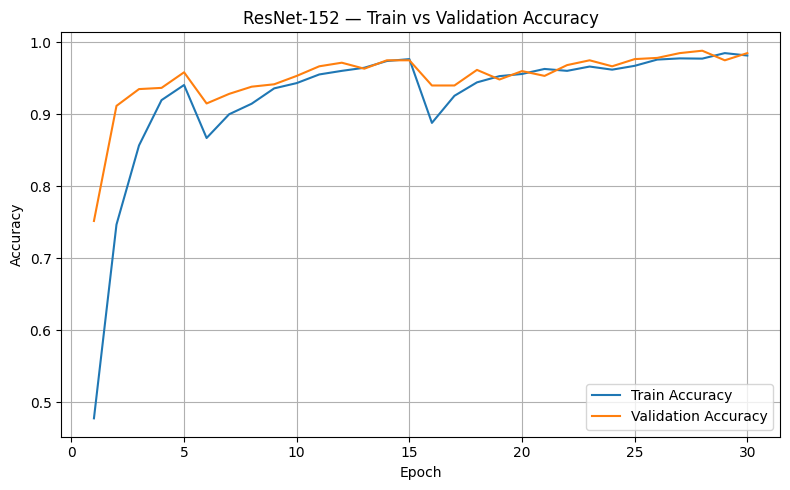

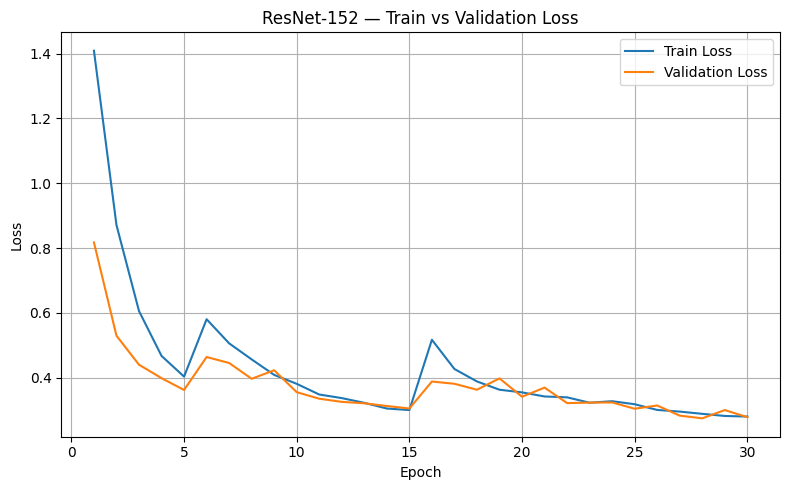

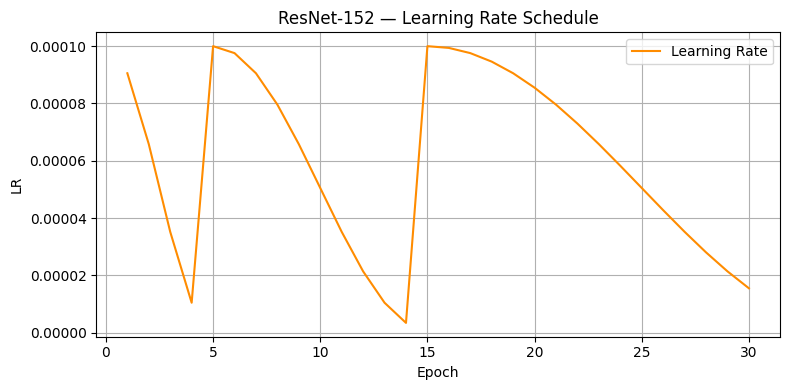


Final Testing on Test Set Only


Final Testing: 100%|██████████| 150/150 [00:03<00:00, 37.81it/s]



Final Test Classification Report:
              precision    recall  f1-score   support

       anger     0.6357    0.8200    0.7162       100
        fear     0.8333    0.9500    0.8879       100
         joy     0.9118    0.9300    0.9208       100
     natural     0.8476    0.8900    0.8683       100
     sadness     0.7755    0.3800    0.5101       100
    surprise     0.8218    0.8300    0.8259       100

    accuracy                         0.8000       600
   macro avg     0.8043    0.8000    0.7882       600
weighted avg     0.8043    0.8000    0.7882       600



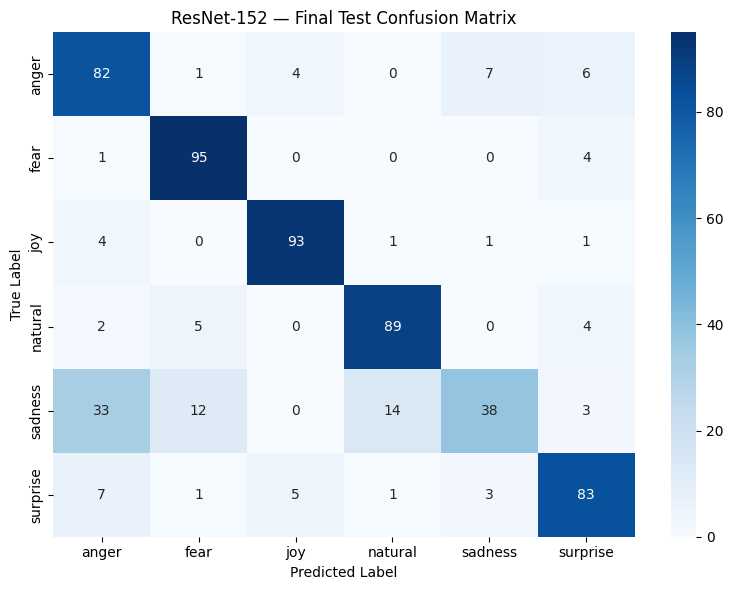


ResNet-152 Final Result:


,model,batch_size,total_parameters,trainable_parameters,best_val_accuracy,final_test_accuracy,test_macro_precision,test_macro_recall,test_macro_f1,test_weighted_precision,test_weighted_recall,test_weighted_f1
0,resnet152,4,58156102,58156102,0.9883,0.8,0.8043,0.8,0.7882,0.8043,0.8,0.7882



Best validation model saved to : /content/drive/MyDrive/Thesis Student/P3 /Group_3_Spring_2025/Update dataset/results/batch_16/resnet152/best_val_model.pth
All files saved inside         : /content/drive/MyDrive/Thesis Student/P3 /Group_3_Spring_2025/Update dataset/results/batch_16/resnet152


In [ ]:
import os
import time
import copy
import torch
import torch.nn as nn
import torch.optim as optim
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from torchvision import datasets, models
from torch.utils.data import DataLoader, ConcatDataset
from tqdm import tqdm
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# ============================================================
# Settings
# ============================================================

RESULTS_DIR_B16 = os.path.join(PROJECT_DIR, "results", "batch_16")
os.makedirs(RESULTS_DIR_B16, exist_ok=True)

# ============================================================
# Datasets — using already defined transform
# ============================================================

train_dataset = datasets.ImageFolder(AUG_TRAIN_DIR, transform=transform)
val_dataset   = datasets.ImageFolder(AUG_VAL_DIR,   transform=transform)
test_dataset  = datasets.ImageFolder(AUG_TEST_DIR,  transform=transform)

if train_dataset.classes != val_dataset.classes:
    raise ValueError("Train and validation class names do not match!")
if train_dataset.classes != test_dataset.classes:
    raise ValueError("Train and test class names do not match!")

class_names = train_dataset.classes
num_classes = len(class_names)

print("Classes          :", class_names)
print("Number of classes:", num_classes)
print("Train images     :", len(train_dataset))
print("Validation images:", len(val_dataset))
print("Test images      :", len(test_dataset))

combined_train_dataset = ConcatDataset([train_dataset, val_dataset])
print("Total training images (train + val):", len(combined_train_dataset))

train_loader = DataLoader(combined_train_dataset, batch_size=BATCH_SIZE, shuffle=True,  num_workers=NUM_WORKERS)
val_loader   = DataLoader(val_dataset,            batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)
test_loader  = DataLoader(test_dataset,           batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)

# ============================================================
# Helper — Parameter Count
# ============================================================

def count_parameters(model):
    total     = sum(p.numel() for p in model.parameters())
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f"  Total parameters    : {total:,}")
    print(f"  Trainable parameters: {trainable:,}")
    return total, trainable

# ============================================================
# Build Model — ResNet-152
# ============================================================

def build_resnet152(num_classes):
    model = models.resnet152(weights=models.ResNet152_Weights.IMAGENET1K_V2)
    # Replace the final fully-connected layer to match num_classes
    in_features = model.fc.in_features
    model.fc = nn.Linear(in_features, num_classes)
    return model

# ============================================================
# Training Function
# ============================================================

def train_resnet152(epochs=EPOCHS, lr=LR, model_folder_name="resnet152"):
    print("\n" + "=" * 90)
    print("Training ResNet-152 | Batch Size: 4")
    print("=" * 90)

    model_output_dir = os.path.join(RESULTS_DIR_B16, model_folder_name)
    os.makedirs(model_output_dir, exist_ok=True)

    model = build_resnet152(num_classes).to(device)

    # ── 1. Parameter summary ──────────────────────────────────
    print("\nModel Parameter Summary:")
    total_params, trainable_params = count_parameters(model)

    criterion = nn.CrossEntropyLoss(label_smoothing=0.05)
    optimizer = optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-4)
    scheduler = optim.lr_scheduler.CosineAnnealingWarmRestarts(optimizer, T_0=5, T_mult=2, eta_min=1e-6)

    # ── 2. Track best validation accuracy ────────────────────
    best_val_acc       = 0.0
    best_model_weights = copy.deepcopy(model.state_dict())
    best_val_path      = os.path.join(model_output_dir, "best_val_model.pth")

    history = {
        "train_loss": [], "train_acc": [],
        "val_loss":   [], "val_acc":   [],
        "lr":         []
    }

    for epoch in range(epochs):
        start_time = time.time()
        model.train()
        train_loss_sum, train_correct, train_total = 0.0, 0, 0

        for images, labels in tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs} Training"):
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(images)
            loss    = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            _, predictions  = torch.max(outputs, 1)
            train_loss_sum += loss.item() * images.size(0)
            train_correct  += torch.sum(predictions == labels).item()
            train_total    += labels.size(0)

        train_loss = train_loss_sum / train_total
        train_acc  = train_correct  / train_total

        model.eval()
        val_loss_sum, val_correct, val_total = 0.0, 0, 0

        with torch.no_grad():
            for images, labels in tqdm(val_loader, desc=f"Epoch {epoch+1}/{epochs} Validation"):
                images, labels = images.to(device), labels.to(device)
                outputs        = model(images)
                loss           = criterion(outputs, labels)
                _, predictions = torch.max(outputs, 1)
                val_loss_sum  += loss.item() * images.size(0)
                val_correct   += torch.sum(predictions == labels).item()
                val_total     += labels.size(0)

        val_loss   = val_loss_sum / val_total
        val_acc    = val_correct  / val_total
        scheduler.step()

        current_lr = optimizer.param_groups[0]['lr']
        history["train_loss"].append(train_loss)
        history["train_acc"].append(train_acc)
        history["val_loss"].append(val_loss)
        history["val_acc"].append(val_acc)
        history["lr"].append(current_lr)

        # ── Save best validation weights ──────────────────────
        if val_acc > best_val_acc:
            best_val_acc       = val_acc
            best_model_weights = copy.deepcopy(model.state_dict())
            torch.save(model.state_dict(), best_val_path)
            saved_flag = "  ✓ best val saved"
        else:
            saved_flag = ""

        print(
            f"Epoch {epoch+1}/{epochs} | "
            f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f} | "
            f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f} | "
            f"LR: {current_lr:.8f} | "
            f"Time: {time.time()-start_time:.1f}s"
            f"{saved_flag}"
        )

    model.load_state_dict(best_model_weights)
    pd.DataFrame(history).to_csv(os.path.join(model_output_dir, "training_history.csv"), index=False)

    epochs_range = range(1, epochs + 1)

    # ── 3a. Accuracy curve ────────────────────────────────────
    plt.figure(figsize=(8, 5))
    plt.plot(epochs_range, history["train_acc"], label="Train Accuracy")
    plt.plot(epochs_range, history["val_acc"],   label="Validation Accuracy")
    plt.title("ResNet-152 — Train vs Validation Accuracy")
    plt.xlabel("Epoch"); plt.ylabel("Accuracy"); plt.legend(); plt.grid(True); plt.tight_layout()
    plt.savefig(os.path.join(model_output_dir, "accuracy_curve.png")); plt.show()

    # ── 3b. Loss curve ────────────────────────────────────────
    plt.figure(figsize=(8, 5))
    plt.plot(epochs_range, history["train_loss"], label="Train Loss")
    plt.plot(epochs_range, history["val_loss"],   label="Validation Loss")
    plt.title("ResNet-152 — Train vs Validation Loss")
    plt.xlabel("Epoch"); plt.ylabel("Loss"); plt.legend(); plt.grid(True); plt.tight_layout()
    plt.savefig(os.path.join(model_output_dir, "loss_curve.png")); plt.show()

    # ── 3c. Learning-rate curve ───────────────────────────────
    plt.figure(figsize=(8, 4))
    plt.plot(epochs_range, history["lr"], color="darkorange", label="Learning Rate")
    plt.title("ResNet-152 — Learning Rate Schedule")
    plt.xlabel("Epoch"); plt.ylabel("LR"); plt.legend(); plt.grid(True); plt.tight_layout()
    plt.savefig(os.path.join(model_output_dir, "lr_curve.png")); plt.show()

    print("\n" + "=" * 90)
    print("Final Testing on Test Set Only")
    print("=" * 90)

    model.eval()
    test_y_true, test_y_pred = [], []

    with torch.no_grad():
        for images, labels in tqdm(test_loader, desc="Final Testing"):
            images, labels = images.to(device), labels.to(device)
            outputs        = model(images)
            _, predictions = torch.max(torch.softmax(outputs, dim=1), 1)
            test_y_true.extend(labels.cpu().numpy())
            test_y_pred.extend(predictions.cpu().numpy())

    print("\nFinal Test Classification Report:")
    print(classification_report(test_y_true, test_y_pred, target_names=class_names, digits=4, zero_division=0))

    cm = confusion_matrix(test_y_true, test_y_pred)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt="d", xticklabels=class_names, yticklabels=class_names, cmap="Blues")
    plt.title("ResNet-152 — Final Test Confusion Matrix")
    plt.xlabel("Predicted Label"); plt.ylabel("True Label"); plt.tight_layout()
    plt.savefig(os.path.join(model_output_dir, "confusion_matrix.png")); plt.show()

    report = classification_report(test_y_true, test_y_pred, target_names=class_names, output_dict=True, zero_division=0)
    pd.DataFrame(report).transpose().to_csv(os.path.join(model_output_dir, "test_classification_report.csv"))
    pd.DataFrame(cm, index=class_names, columns=class_names).to_csv(os.path.join(model_output_dir, "test_confusion_matrix.csv"))

    result = {
        "model":                   model_folder_name,
        "batch_size":              4,
        "total_parameters":        total_params,
        "trainable_parameters":    trainable_params,
        "best_val_accuracy":       round(best_val_acc, 4),
        "final_test_accuracy":     round(accuracy_score(test_y_true, test_y_pred), 4),
        "test_macro_precision":    round(report["macro avg"]["precision"], 4),
        "test_macro_recall":       round(report["macro avg"]["recall"], 4),
        "test_macro_f1":           round(report["macro avg"]["f1-score"], 4),
        "test_weighted_precision": round(report["weighted avg"]["precision"], 4),
        "test_weighted_recall":    round(report["weighted avg"]["recall"], 4),
        "test_weighted_f1":        round(report["weighted avg"]["f1-score"], 4)
    }

    result_df = pd.DataFrame([result])
    result_df.to_csv(os.path.join(model_output_dir, "resnet152_result_summary.csv"), index=False)
    print("\nResNet-152 Final Result:"); display(result_df)
    print(f"\nBest validation model saved to : {best_val_path}")
    print("All files saved inside         :", model_output_dir)
    return result, model

resnet152_result, resnet152_model = train_resnet152(
    epochs=EPOCHS, lr=LR, model_folder_name="resnet152"
)

#Maxvit Improved (Freeze + Dense) =0.7650

Classes          : ['anger', 'fear', 'joy', 'natural', 'sadness', 'surprise']
Number of classes: 6
Train images     : 2400
Validation images: 600
Test images      : 600
Total training images (train + val): 3000

Training MaxViT-Tiny | Batch Size: 4 | Freeze Stages: 1
[Freezing] Stem + 1 stages frozen (329,640 parameters locked)

MODEL PARAMETER SUMMARY
Total Parameters     : 31,590,094
Trainable Parameters : 31,260,454
Frozen Parameters    : 329,640



Epoch 1/30 Validation: 100%|██████████| 75/75 [00:03<00:00, 20.72it/s]


Epoch 1/30 | Train Loss: 1.7682 | Train Acc: 0.2473 | Val Loss: 1.5447 | Val Acc: 0.4733 | LR backbone: 9.78e-06 | LR head: 9.76e-05 | Time: 728.8s  ✓ best val saved


Epoch 2/30 Validation: 100%|██████████| 75/75 [00:03<00:00, 21.44it/s]


Epoch 2/30 | Train Loss: 1.5703 | Train Acc: 0.4067 | Val Loss: 1.2889 | Val Acc: 0.6183 | LR backbone: 9.14e-06 | LR head: 9.05e-05 | Time: 50.9s  ✓ best val saved


...

Epoch 28/30 | Train Loss: 0.6337 | Train Acc: 0.9170 | Val Loss: 0.5060 | Val Acc: 0.9650 | LR backbone: 1.22e-06 | LR head: 3.42e-06 | Time: 48.4s


Epoch 29/30 Validation: 100%|██████████| 75/75 [00:03<00:00, 21.20it/s]


Epoch 29/30 | Train Loss: 0.6216 | Train Acc: 0.9230 | Val Loss: 0.4974 | Val Acc: 0.9750 | LR backbone: 1.06e-06 | LR head: 1.61e-06 | Time: 48.8s


Epoch 30/30 Validation: 100%|██████████| 75/75 [00:03<00:00, 20.44it/s]


Epoch 30/30 | Train Loss: 0.6319 | Train Acc: 0.9207 | Val Loss: 0.5053 | Val Acc: 0.9667 | LR backbone: 1.00e-05 | LR head: 1.00e-04 | Time: 48.4s


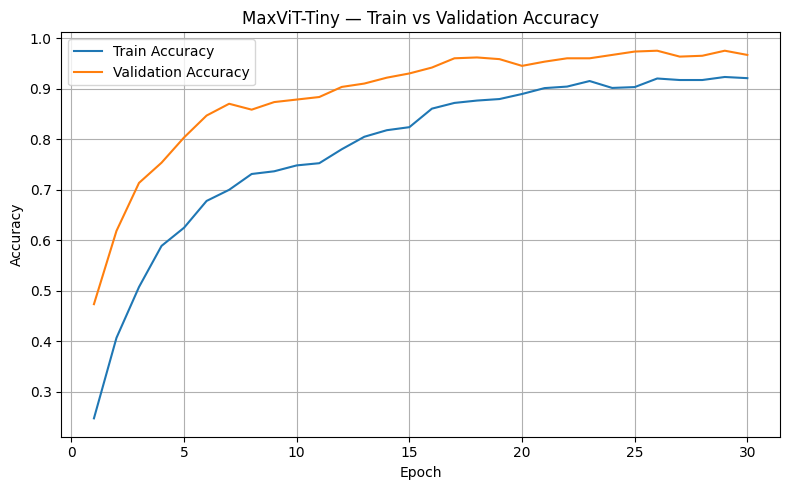

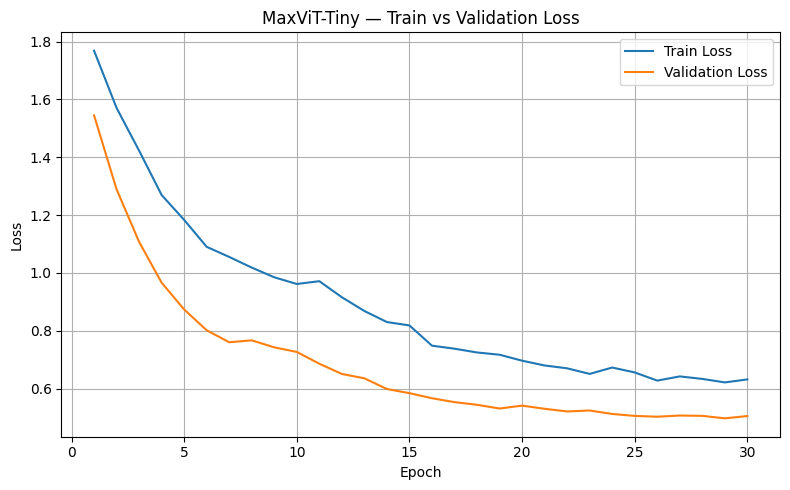

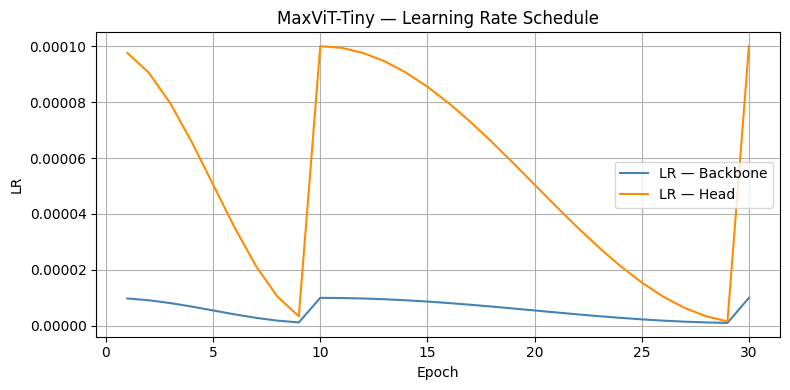


Final Testing on Test Set Only


Final Testing: 100%|██████████| 75/75 [03:45<00:00,  3.00s/it]



Final Test Classification Report:
              precision    recall  f1-score   support

       anger     0.6615    0.8600    0.7478       100
        fear     0.8000    0.9200    0.8558       100
         joy     0.8447    0.8700    0.8571       100
     natural     0.7982    0.8700    0.8325       100
     sadness     0.6226    0.3300    0.4314       100
    surprise     0.8222    0.7400    0.7789       100

    accuracy                         0.7650       600
   macro avg     0.7582    0.7650    0.7506       600
weighted avg     0.7582    0.7650    0.7506       600



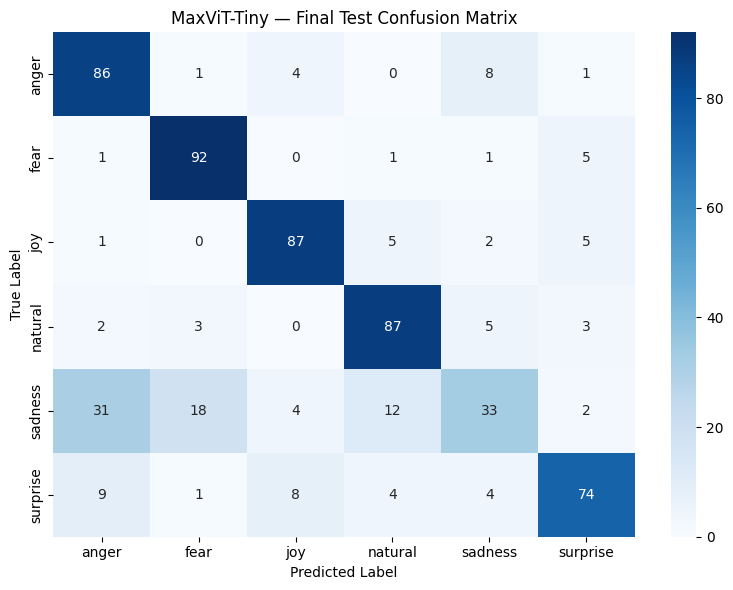


MaxViT-Tiny Final Result:


,model,batch_size,freeze_stages,total_parameters,trainable_parameters,best_val_accuracy,final_test_accuracy,test_macro_precision,test_macro_recall,test_macro_f1,test_weighted_precision,test_weighted_recall,test_weighted_f1
0,maxvit_frozen_model,4,1,31590094,31260454,0.975,0.765,0.7582,0.765,0.7506,0.7582,0.765,0.7506



Best validation model saved to : /content/drive/MyDrive/Thesis Student/P3 /Group_3_Spring_2025/Update dataset/results/batch_16/maxvit_frozen_model/best_val_model.pth
All files saved inside         : /content/drive/MyDrive/Thesis Student/P3 /Group_3_Spring_2025/Update dataset/results/batch_16/maxvit_frozen_model


In [ ]:
# ============================================================
# MaxViT Only Classification Model — Improved (Freeze + Dense)
# ============================================================

import os
import gc
import time
import copy
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import timm
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from torchvision import datasets
from torch.utils.data import DataLoader, ConcatDataset
from tqdm import tqdm
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.utils.class_weight import compute_class_weight

# ============================================================
# Memory Optimization
# ============================================================

os.environ["PYTORCH_ALLOC_CONF"] = "expandable_segments:True"
torch.cuda.empty_cache()
gc.collect()

# ============================================================
# Settings
# ============================================================

RESULTS_DIR_B16 = os.path.join(PROJECT_DIR, "results", "batch_16")
os.makedirs(RESULTS_DIR_B16, exist_ok=True)

# ============================================================
# Datasets
# ============================================================

train_dataset = datasets.ImageFolder(AUG_TRAIN_DIR, transform=transform)
val_dataset   = datasets.ImageFolder(AUG_VAL_DIR,   transform=transform)
test_dataset  = datasets.ImageFolder(AUG_TEST_DIR,  transform=transform)

if train_dataset.classes != val_dataset.classes:
    raise ValueError("Train and validation class names do not match!")
if train_dataset.classes != test_dataset.classes:
    raise ValueError("Train and test class names do not match!")

class_names = train_dataset.classes
num_classes = len(class_names)

print("Classes          :", class_names)
print("Number of classes:", num_classes)
print("Train images     :", len(train_dataset))
print("Validation images:", len(val_dataset))
print("Test images      :", len(test_dataset))

combined_train_dataset = ConcatDataset([train_dataset, val_dataset])
print("Total training images (train + val):", len(combined_train_dataset))

train_loader = DataLoader(combined_train_dataset, batch_size=8, shuffle=True,
                          num_workers=NUM_WORKERS, pin_memory=True)
val_loader   = DataLoader(val_dataset,  batch_size=8, shuffle=False,
                          num_workers=NUM_WORKERS, pin_memory=True)
test_loader  = DataLoader(test_dataset, batch_size=8, shuffle=False,
                          num_workers=NUM_WORKERS, pin_memory=True)

# ============================================================
# Class Weights
# ============================================================

_train_labels        = [label for _, label in train_dataset.samples]
_class_weights_np    = compute_class_weight(
    class_weight="balanced",
    classes=np.arange(num_classes),
    y=_train_labels
)
class_weights_tensor = torch.tensor(_class_weights_np, dtype=torch.float)

# ============================================================
# Helper — Parameter Count
# ============================================================

def count_parameters(model):
    total     = sum(p.numel() for p in model.parameters())
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    frozen    = total - trainable
    print("\n===================================")
    print("MODEL PARAMETER SUMMARY")
    print("===================================")
    print(f"Total Parameters     : {total:,}")
    print(f"Trainable Parameters : {trainable:,}")
    print(f"Frozen Parameters    : {frozen:,}")
    print("===================================\n")
    return total, trainable

# ============================================================
# MaxViT Model — Selective Freezing + Improved Head
# ============================================================

class MaxViTClassifier(nn.Module):

    def __init__(self, num_classes, freeze_stages=2):
        super(MaxViTClassifier, self).__init__()

        self.backbone = timm.create_model(
            "maxvit_tiny_tf_224.in1k",
            pretrained=True,
            num_classes=0           # remove built-in head
        )

        self._freeze_backbone_stages(freeze_stages)

        in_features = self.backbone.num_features  # 512 for maxvit_tiny

        self.classifier = nn.Sequential(
            # Block 1
            nn.Linear(in_features, 1024),
            nn.BatchNorm1d(1024),
            nn.GELU(),
            nn.Dropout(0.5),

            # Block 2
            nn.Linear(1024, 512),
            nn.BatchNorm1d(512),
            nn.GELU(),
            nn.Dropout(0.4),

            # Block 3
            nn.Linear(512, 256),
            nn.BatchNorm1d(256),
            nn.GELU(),
            nn.Dropout(0.3),

            # Output
            nn.Linear(256, num_classes)
        )

    def _freeze_backbone_stages(self, freeze_stages):
        for param in self.backbone.stem.parameters():
            param.requires_grad = False

        for stage_idx, stage in enumerate(self.backbone.stages):
            if stage_idx < freeze_stages:
                for param in stage.parameters():
                    param.requires_grad = False

        frozen = sum(p.numel() for p in self.backbone.parameters()
                     if not p.requires_grad)
        print(f"[Freezing] Stem + {freeze_stages} stages frozen "
              f"({frozen:,} parameters locked)")

    def forward(self, x):
        features = self.backbone(x)
        return self.classifier(features)

# ============================================================
# Training Function
# ============================================================

def train_maxvit(
    epochs=EPOCHS,
    lr=LR,
    model_folder_name="maxvit_frozen_model",
    freeze_stages=2
):
    print("\n" + "=" * 90)
    print("Training MaxViT-Tiny | Batch Size: 4 | Freeze Stages:", freeze_stages)
    print("=" * 90)

    model_output_dir = os.path.join(RESULTS_DIR_B16, model_folder_name)
    os.makedirs(model_output_dir, exist_ok=True)

    model = MaxViTClassifier(num_classes, freeze_stages=freeze_stages).to(device)

    # ── 1. Parameter summary ──────────────────────────────────
    total_params, trainable_params = count_parameters(model)

    criterion = nn.CrossEntropyLoss(
        weight=class_weights_tensor.to(device),
        label_smoothing=0.1
    )

    # ── Differential learning rates ───────────────────────────
    backbone_params   = [p for p in model.backbone.parameters()   if p.requires_grad]
    classifier_params = [p for p in model.classifier.parameters() if p.requires_grad]

    optimizer = optim.AdamW([
        {"params": backbone_params,   "lr": lr * 0.1},
        {"params": classifier_params, "lr": lr},
    ], weight_decay=2e-4)

    scheduler = optim.lr_scheduler.CosineAnnealingWarmRestarts(
        optimizer, T_0=10, T_mult=2, eta_min=1e-6
    )

    scaler = torch.amp.GradScaler("cuda")

    # ── 2. Track best validation accuracy ────────────────────
    best_val_acc       = 0.0
    best_model_weights = copy.deepcopy(model.state_dict())
    best_val_path      = os.path.join(model_output_dir, "best_val_model.pth")

    history = {
        "train_loss": [], "train_acc": [],
        "val_loss":   [], "val_acc":   [],
        "lr_backbone": [], "lr_head":  []
    }

    # ============================================================
    # Training Loop
    # ============================================================

    for epoch in range(epochs):
        start_time = time.time()
        model.train()
        train_loss_sum, train_correct, train_total = 0.0, 0, 0

        for images, labels in tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs} Training"):
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()

            with torch.amp.autocast("cuda"):
                outputs = model(images)
                loss    = criterion(outputs, labels)

            scaler.scale(loss).backward()
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            scaler.step(optimizer)
            scaler.update()

            _, predictions  = torch.max(outputs, 1)
            train_loss_sum += loss.item() * images.size(0)
            train_correct  += torch.sum(predictions == labels).item()
            train_total    += labels.size(0)

        train_loss = train_loss_sum / train_total
        train_acc  = train_correct  / train_total

        # ── Validation ────────────────────────────────────────
        model.eval()
        val_loss_sum, val_correct, val_total = 0.0, 0, 0

        with torch.no_grad():
            for images, labels in tqdm(val_loader, desc=f"Epoch {epoch+1}/{epochs} Validation"):
                images, labels = images.to(device), labels.to(device)

                with torch.amp.autocast("cuda"):
                    outputs = model(images)
                    loss    = criterion(outputs, labels)

                _, predictions = torch.max(outputs, 1)
                val_loss_sum  += loss.item() * images.size(0)
                val_correct   += torch.sum(predictions == labels).item()
                val_total     += labels.size(0)

        val_loss = val_loss_sum / val_total
        val_acc  = val_correct  / val_total
        scheduler.step()

        lr_backbone = optimizer.param_groups[0]['lr']
        lr_head     = optimizer.param_groups[1]['lr']

        history["train_loss"].append(train_loss)
        history["train_acc"].append(train_acc)
        history["val_loss"].append(val_loss)
        history["val_acc"].append(val_acc)
        history["lr_backbone"].append(lr_backbone)
        history["lr_head"].append(lr_head)

        # ── Save best validation weights ──────────────────────
        if val_acc > best_val_acc:
            best_val_acc       = val_acc
            best_model_weights = copy.deepcopy(model.state_dict())
            torch.save(model.state_dict(), best_val_path)
            saved_flag = "  ✓ best val saved"
        else:
            saved_flag = ""

        print(
            f"Epoch {epoch+1}/{epochs} | "
            f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f} | "
            f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f} | "
            f"LR backbone: {lr_backbone:.2e} | LR head: {lr_head:.2e} | "
            f"Time: {time.time()-start_time:.1f}s"
            f"{saved_flag}"
        )

    # ── Load best weights for testing ─────────────────────────
    model.load_state_dict(best_model_weights)
    pd.DataFrame(history).to_csv(os.path.join(model_output_dir, "training_history.csv"), index=False)

    epochs_range = range(1, epochs + 1)

    # ── 3a. Accuracy curve ────────────────────────────────────
    plt.figure(figsize=(8, 5))
    plt.plot(epochs_range, history["train_acc"], label="Train Accuracy")
    plt.plot(epochs_range, history["val_acc"],   label="Validation Accuracy")
    plt.title("MaxViT-Tiny — Train vs Validation Accuracy")
    plt.xlabel("Epoch"); plt.ylabel("Accuracy"); plt.legend(); plt.grid(True); plt.tight_layout()
    plt.savefig(os.path.join(model_output_dir, "accuracy_curve.png")); plt.show()

    # ── 3b. Loss curve ────────────────────────────────────────
    plt.figure(figsize=(8, 5))
    plt.plot(epochs_range, history["train_loss"], label="Train Loss")
    plt.plot(epochs_range, history["val_loss"],   label="Validation Loss")
    plt.title("MaxViT-Tiny — Train vs Validation Loss")
    plt.xlabel("Epoch"); plt.ylabel("Loss"); plt.legend(); plt.grid(True); plt.tight_layout()
    plt.savefig(os.path.join(model_output_dir, "loss_curve.png")); plt.show()

    # ── 3c. Learning-rate curve (both param groups) ───────────
    plt.figure(figsize=(8, 4))
    plt.plot(epochs_range, history["lr_backbone"], label="LR — Backbone", color="steelblue")
    plt.plot(epochs_range, history["lr_head"],     label="LR — Head",     color="darkorange")
    plt.title("MaxViT-Tiny — Learning Rate Schedule")
    plt.xlabel("Epoch"); plt.ylabel("LR"); plt.legend(); plt.grid(True); plt.tight_layout()
    plt.savefig(os.path.join(model_output_dir, "lr_curve.png")); plt.show()

    # ── Final test ────────────────────────────────────────────
    print("\n" + "=" * 90)
    print("Final Testing on Test Set Only")
    print("=" * 90)

    model.eval()
    test_y_true, test_y_pred = [], []

    with torch.no_grad():
        for images, labels in tqdm(test_loader, desc="Final Testing"):
            images = images.to(device)
            with torch.amp.autocast("cuda"):
                outputs = model(images)
            _, predictions = torch.max(torch.softmax(outputs, dim=1), 1)
            test_y_true.extend(labels.numpy())
            test_y_pred.extend(predictions.cpu().numpy())

    print("\nFinal Test Classification Report:")
    print(classification_report(test_y_true, test_y_pred,
                                 target_names=class_names, digits=4, zero_division=0))

    cm = confusion_matrix(test_y_true, test_y_pred)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt="d", xticklabels=class_names,
                yticklabels=class_names, cmap="Blues")
    plt.title("MaxViT-Tiny — Final Test Confusion Matrix")
    plt.xlabel("Predicted Label"); plt.ylabel("True Label"); plt.tight_layout()
    plt.savefig(os.path.join(model_output_dir, "confusion_matrix.png")); plt.show()

    report = classification_report(test_y_true, test_y_pred,
                                    target_names=class_names,
                                    output_dict=True, zero_division=0)
    pd.DataFrame(report).transpose().to_csv(
        os.path.join(model_output_dir, "test_classification_report.csv"))
    pd.DataFrame(cm, index=class_names, columns=class_names).to_csv(
        os.path.join(model_output_dir, "test_confusion_matrix.csv"))

    result = {
        "model":                   model_folder_name,
        "batch_size":              4,
        "freeze_stages":           freeze_stages,
        "total_parameters":        total_params,
        "trainable_parameters":    trainable_params,
        "best_val_accuracy":       round(best_val_acc, 4),
        "final_test_accuracy":     round(accuracy_score(test_y_true, test_y_pred), 4),
        "test_macro_precision":    round(report["macro avg"]["precision"], 4),
        "test_macro_recall":       round(report["macro avg"]["recall"], 4),
        "test_macro_f1":           round(report["macro avg"]["f1-score"], 4),
        "test_weighted_precision": round(report["weighted avg"]["precision"], 4),
        "test_weighted_recall":    round(report["weighted avg"]["recall"], 4),
        "test_weighted_f1":        round(report["weighted avg"]["f1-score"], 4)
    }

    result_df = pd.DataFrame([result])
    result_df.to_csv(os.path.join(model_output_dir, "maxvit_result_summary.csv"), index=False)
    print("\nMaxViT-Tiny Final Result:"); display(result_df)
    print(f"\nBest validation model saved to : {best_val_path}")
    print("All files saved inside         :", model_output_dir)
    return result, model

# ============================================================
# Run
# ============================================================

maxvit_result, maxvit_model = train_maxvit(
    epochs=EPOCHS,
    lr=LR,
    model_folder_name="maxvit_frozen_model",
    freeze_stages=1
)

#MaxViT Only Classification = .8133


MODEL PARAMETER SUMMARY
Total Parameters     : 30,800,590
Trainable Parameters : 30,800,590



100%|██████████| 375/375 [00:50<00:00,  7.38it/s]


Epoch 1/30 | Train Acc: 0.4057 | Val Acc: 0.7050


100%|██████████| 375/375 [00:49<00:00,  7.50it/s]


Epoch 2/30 | Train Acc: 0.7223 | Val Acc: 0.8633


...

Epoch 28/30 | Train Acc: 0.9857 | Val Acc: 0.9950


100%|██████████| 375/375 [00:51<00:00,  7.26it/s]


Epoch 29/30 | Train Acc: 0.9813 | Val Acc: 1.0000


100%|██████████| 375/375 [00:52<00:00,  7.19it/s]


Epoch 30/30 | Train Acc: 0.9853 | Val Acc: 0.9933

Classification Report:

              precision    recall  f1-score   support

       anger     0.7217    0.8300    0.7721       100
        fear     0.8440    0.9200    0.8804       100
         joy     0.9000    0.9900    0.9429       100
     natural     0.8476    0.8900    0.8683       100
     sadness     0.7692    0.4000    0.5263       100
    surprise     0.7798    0.8500    0.8134       100

    accuracy                         0.8133       600
   macro avg     0.8104    0.8133    0.8006       600
weighted avg     0.8104    0.8133    0.8006       600



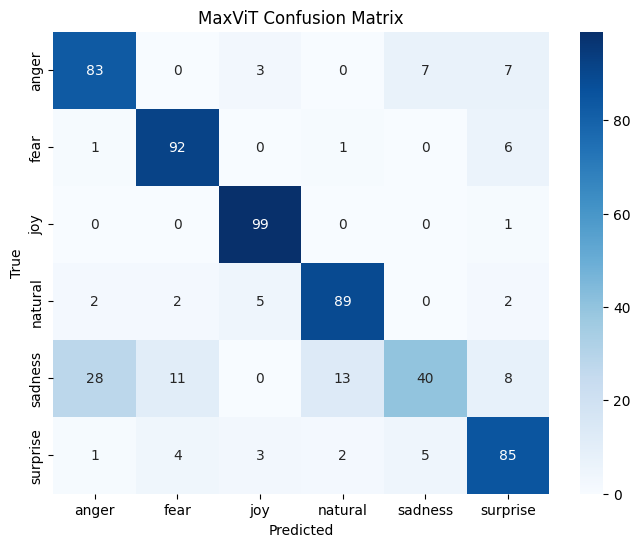

In [ ]:
# ============================================================
# MaxViT Only Classification Model
# ============================================================

import os
import gc
import time
import copy
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import timm
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from torchvision import datasets
from torch.utils.data import DataLoader, ConcatDataset
from tqdm import tqdm
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.utils.class_weight import compute_class_weight

# ============================================================
# Memory Optimization
# ============================================================

os.environ["PYTORCH_ALLOC_CONF"] = "expandable_segments:True"
torch.cuda.empty_cache()
gc.collect()

# ============================================================
# Dataset
# ============================================================

train_dataset = datasets.ImageFolder(AUG_TRAIN_DIR, transform=transform)
val_dataset   = datasets.ImageFolder(AUG_VAL_DIR, transform=transform)
test_dataset  = datasets.ImageFolder(AUG_TEST_DIR, transform=transform)

class_names = train_dataset.classes
num_classes = len(class_names)

combined_train_dataset = ConcatDataset([train_dataset, val_dataset])

train_loader = DataLoader(
    combined_train_dataset,
    batch_size=8,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=8,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=8,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True
)

# ============================================================
# Class Weights
# ============================================================

_train_labels = [label for _, label in train_dataset.samples]

_class_weights_np = compute_class_weight(
    class_weight="balanced",
    classes=np.arange(num_classes),
    y=_train_labels
)

class_weights_tensor = torch.tensor(
    _class_weights_np,
    dtype=torch.float
)

# ============================================================
# MaxViT Model
# ============================================================

class MaxViTClassifier(nn.Module):

    def __init__(self, num_classes):
        super(MaxViTClassifier, self).__init__()

        self.backbone = timm.create_model(
            "maxvit_tiny_tf_224.in1k",
            pretrained=True,
            num_classes=0
        )

        in_features = self.backbone.num_features

        self.classifier = nn.Sequential(
            nn.Linear(in_features, 512),
            nn.BatchNorm1d(512),
            nn.GELU(),
            nn.Dropout(0.3),

            nn.Linear(512, 256),
            nn.BatchNorm1d(256),
            nn.GELU(),
            nn.Dropout(0.2),

            nn.Linear(256, num_classes)
        )

    def forward(self, x):

        features = self.backbone(x)
        output = self.classifier(features)

        return output

# ============================================================
# Parameter Summary
# ============================================================

def print_parameter_summary(model):

    total_params = sum(p.numel() for p in model.parameters())

    trainable_params = sum(
        p.numel() for p in model.parameters()
        if p.requires_grad
    )

    print("\n===================================")
    print("MODEL PARAMETER SUMMARY")
    print("===================================")
    print(f"Total Parameters     : {total_params:,}")
    print(f"Trainable Parameters : {trainable_params:,}")
    print("===================================\n")

# ============================================================
# Training Function
# ============================================================

def train_maxvit(
    epochs=30,
    lr=LR,
    model_folder_name="maxvit_only_model"
):

    model_output_dir = os.path.join(
        RESULTS_DIR_B16,
        model_folder_name
    )

    os.makedirs(model_output_dir, exist_ok=True)

    model = MaxViTClassifier(num_classes).to(device)

    print_parameter_summary(model)

    criterion = nn.CrossEntropyLoss(
        weight=class_weights_tensor.to(device),
        label_smoothing=0.05
    )

    optimizer = optim.AdamW(
        model.parameters(),
        lr=lr,
        weight_decay=1e-4
    )

    scheduler = optim.lr_scheduler.CosineAnnealingWarmRestarts(
        optimizer,
        T_0=10,
        T_mult=2,
        eta_min=1e-6
    )

    scaler = torch.amp.GradScaler("cuda")

    best_val_acc = 0.0
    best_model_weights = copy.deepcopy(model.state_dict())

    history = {
        "train_loss": [],
        "train_acc": [],
        "val_loss": [],
        "val_acc": []
    }

    # ========================================================
    # Training Loop
    # ========================================================

    for epoch in range(epochs):

        model.train()

        train_loss_sum = 0.0
        train_correct = 0
        train_total = 0

        for images, labels in tqdm(train_loader):

            images = images.to(device)
            labels = labels.to(device)

            optimizer.zero_grad()

            with torch.amp.autocast("cuda"):

                outputs = model(images)
                loss = criterion(outputs, labels)

            scaler.scale(loss).backward()

            scaler.unscale_(optimizer)

            torch.nn.utils.clip_grad_norm_(
                model.parameters(),
                max_norm=1.0
            )

            scaler.step(optimizer)
            scaler.update()

            _, preds = torch.max(outputs, 1)

            train_loss_sum += loss.item() * images.size(0)
            train_correct += torch.sum(preds == labels).item()
            train_total += labels.size(0)

        train_loss = train_loss_sum / train_total
        train_acc = train_correct / train_total

        # ====================================================
        # Validation
        # ====================================================

        model.eval()

        val_loss_sum = 0.0
        val_correct = 0
        val_total = 0

        with torch.no_grad():

            for images, labels in val_loader:

                images = images.to(device)
                labels = labels.to(device)

                with torch.amp.autocast("cuda"):

                    outputs = model(images)
                    loss = criterion(outputs, labels)

                _, preds = torch.max(outputs, 1)

                val_loss_sum += loss.item() * images.size(0)
                val_correct += torch.sum(preds == labels).item()
                val_total += labels.size(0)

        val_loss = val_loss_sum / val_total
        val_acc = val_correct / val_total

        scheduler.step()

        history["train_loss"].append(train_loss)
        history["train_acc"].append(train_acc)
        history["val_loss"].append(val_loss)
        history["val_acc"].append(val_acc)

        if val_acc > best_val_acc:

            best_val_acc = val_acc

            best_model_weights = copy.deepcopy(
                model.state_dict()
            )

            torch.save(
                model.state_dict(),
                os.path.join(model_output_dir, "best_model.pth")
            )

        print(
            f"Epoch {epoch+1}/{epochs} | "
            f"Train Acc: {train_acc:.4f} | "
            f"Val Acc: {val_acc:.4f}"
        )

    # ========================================================
    # Load Best Model
    # ========================================================

    model.load_state_dict(best_model_weights)

    # ========================================================
    # Testing
    # ========================================================

    model.eval()

    y_true = []
    y_pred = []

    with torch.no_grad():

        for images, labels in test_loader:

            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)

            _, preds = torch.max(outputs, 1)

            y_true.extend(labels.cpu().numpy())
            y_pred.extend(preds.cpu().numpy())

    print("\nClassification Report:\n")

    print(
        classification_report(
            y_true,
            y_pred,
            target_names=class_names,
            digits=4
        )
    )

    cm = confusion_matrix(y_true, y_pred)

    plt.figure(figsize=(8,6))

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=class_names,
        yticklabels=class_names
    )

    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.title("MaxViT Confusion Matrix")

    plt.show()

    return model

# ============================================================
# Run
# ============================================================

maxvit_model = train_maxvit(
    epochs=30,
    lr=LR,
    model_folder_name="maxvit_only_model"
)

# Densenet169= .8083

Classes          : ['anger', 'fear', 'joy', 'natural', 'sadness', 'surprise']
Number of classes: 6
Train images     : 2400
Validation images: 600
Test images      : 600
Total training images (train + val): 3000

Training DenseNet-169 | Batch Size: 4
Downloading: "https://download.pytorch.org/models/densenet169-b2777c0a.pth" to /root/.cache/torch/hub/checkpoints/densenet169-b2777c0a.pth


100%|██████████| 54.7M/54.7M [00:00<00:00, 240MB/s]



Model Parameter Summary:
  Total parameters    : 12,494,470
  Trainable parameters: 12,494,470


Epoch 1/30 Validation: 100%|██████████| 150/150 [00:04<00:00, 32.61it/s]


Epoch 1/30 | Train Loss: 1.4029 | Train Acc: 0.4717 | Val Loss: 0.8093 | Val Acc: 0.7767 | LR: 0.00009055 | Time: 75.3s  ✓ best val saved


...

Epoch 28/30 | Train Loss: 0.3222 | Train Acc: 0.9713 | Val Loss: 0.2956 | Val Acc: 0.9867 | LR: 0.00002803 | Time: 76.2s  ✓ best val saved


Epoch 29/30 Validation: 100%|██████████| 150/150 [00:04<00:00, 32.32it/s]


Epoch 29/30 | Train Loss: 0.3145 | Train Acc: 0.9783 | Val Loss: 0.2878 | Val Acc: 0.9883 | LR: 0.00002140 | Time: 77.3s  ✓ best val saved


Epoch 30/30 Validation: 100%|██████████| 150/150 [00:04<00:00, 32.96it/s]


Epoch 30/30 | Train Loss: 0.3019 | Train Acc: 0.9793 | Val Loss: 0.2918 | Val Acc: 0.9850 | LR: 0.00001550 | Time: 77.5s


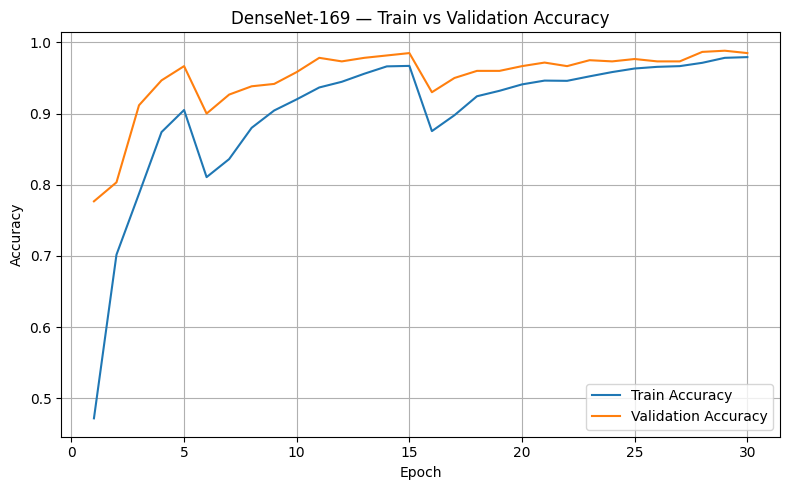

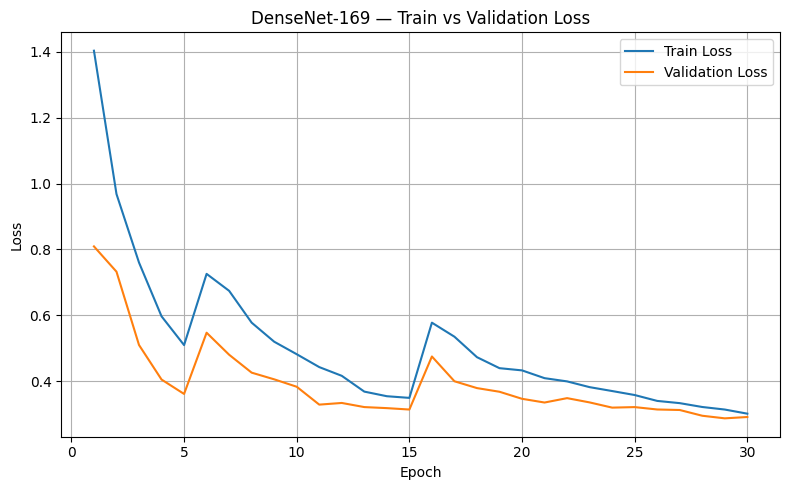

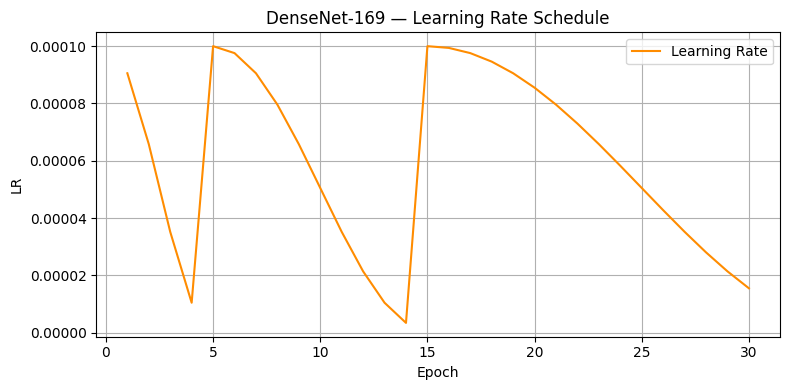


Final Testing on Test Set Only


Final Testing: 100%|██████████| 150/150 [00:04<00:00, 33.35it/s]



Final Test Classification Report:
              precision    recall  f1-score   support

       anger     0.7297    0.8100    0.7678       100
        fear     0.8807    0.9600    0.9187       100
         joy     0.8509    0.9700    0.9065       100
     natural     0.7778    0.9100    0.8387       100
     sadness     0.6667    0.3800    0.4841       100
    surprise     0.8913    0.8200    0.8542       100

    accuracy                         0.8083       600
   macro avg     0.7995    0.8083    0.7950       600
weighted avg     0.7995    0.8083    0.7950       600



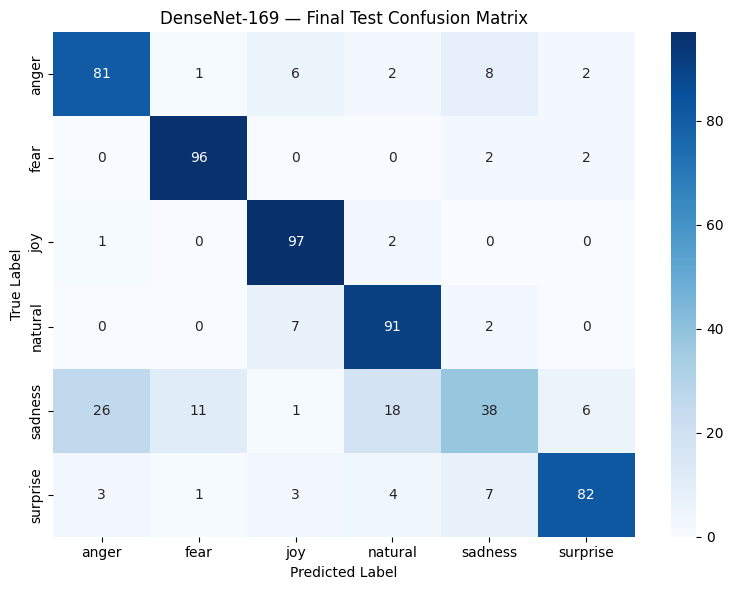


DenseNet-169 Final Result:


,model,batch_size,total_parameters,trainable_parameters,best_val_accuracy,final_test_accuracy,test_macro_precision,test_macro_recall,test_macro_f1,test_weighted_precision,test_weighted_recall,test_weighted_f1
0,densenet169,4,12494470,12494470,0.9883,0.8083,0.7995,0.8083,0.795,0.7995,0.8083,0.795



Best validation model saved to : /content/drive/MyDrive/Thesis Student/P3 /Group_3_Spring_2025/Update dataset/results/batch_4/densenet169/best_val_model.pth
All files saved inside         : /content/drive/MyDrive/Thesis Student/P3 /Group_3_Spring_2025/Update dataset/results/batch_4/densenet169


In [ ]:
import os
import time
import copy
import torch
import torch.nn as nn
import torch.optim as optim
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from torchvision import datasets, models
from torch.utils.data import DataLoader, ConcatDataset
from tqdm import tqdm
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# ============================================================
# Settings
# ============================================================

RESULTS_DIR_B16 = os.path.join(PROJECT_DIR, "results", "batch_4")
os.makedirs(RESULTS_DIR_B16, exist_ok=True)

# ============================================================
# Datasets — using already defined transform
# ============================================================

train_dataset = datasets.ImageFolder(AUG_TRAIN_DIR, transform=transform)
val_dataset   = datasets.ImageFolder(AUG_VAL_DIR,   transform=transform)
test_dataset  = datasets.ImageFolder(AUG_TEST_DIR,  transform=transform)

if train_dataset.classes != val_dataset.classes:
    raise ValueError("Train and validation class names do not match!")
if train_dataset.classes != test_dataset.classes:
    raise ValueError("Train and test class names do not match!")

class_names = train_dataset.classes
num_classes = len(class_names)

print("Classes          :", class_names)
print("Number of classes:", num_classes)
print("Train images     :", len(train_dataset))
print("Validation images:", len(val_dataset))
print("Test images      :", len(test_dataset))

combined_train_dataset = ConcatDataset([train_dataset, val_dataset])
print("Total training images (train + val):", len(combined_train_dataset))

train_loader = DataLoader(combined_train_dataset, batch_size=BATCH_SIZE, shuffle=True,  num_workers=NUM_WORKERS)
val_loader   = DataLoader(val_dataset,            batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)
test_loader  = DataLoader(test_dataset,           batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)

# ============================================================
# Helper — Parameter Count
# ============================================================

def count_parameters(model):
    total     = sum(p.numel() for p in model.parameters())
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f"  Total parameters    : {total:,}")
    print(f"  Trainable parameters: {trainable:,}")
    return total, trainable

# ============================================================
# Build Model — DenseNet-169
# ============================================================

def build_densenet169(num_classes):
    model = models.densenet169(weights=models.DenseNet169_Weights.IMAGENET1K_V1)
    # DenseNet uses model.classifier (a single Linear layer)
    in_features     = model.classifier.in_features
    model.classifier = nn.Linear(in_features, num_classes)
    return model

# ============================================================
# Training Function
# ============================================================

def train_densenet169(epochs=EPOCHS, lr=LR, model_folder_name="densenet169"):
    print("\n" + "=" * 90)
    print("Training DenseNet-169 | Batch Size: 4")
    print("=" * 90)

    model_output_dir = os.path.join(RESULTS_DIR_B16, model_folder_name)
    os.makedirs(model_output_dir, exist_ok=True)

    model = build_densenet169(num_classes).to(device)

    # ── 1. Parameter summary ──────────────────────────────────
    print("\nModel Parameter Summary:")
    total_params, trainable_params = count_parameters(model)

    criterion = nn.CrossEntropyLoss(label_smoothing=0.05)
    optimizer = optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-4)
    scheduler = optim.lr_scheduler.CosineAnnealingWarmRestarts(optimizer, T_0=5, T_mult=2, eta_min=1e-6)

    # ── 2. Track best validation accuracy ────────────────────
    best_val_acc       = 0.0
    best_model_weights = copy.deepcopy(model.state_dict())
    best_val_path      = os.path.join(model_output_dir, "best_val_model.pth")

    history = {
        "train_loss": [], "train_acc": [],
        "val_loss":   [], "val_acc":   [],
        "lr":         []
    }

    for epoch in range(epochs):
        start_time = time.time()
        model.train()
        train_loss_sum, train_correct, train_total = 0.0, 0, 0

        for images, labels in tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs} Training"):
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(images)
            loss    = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            _, predictions  = torch.max(outputs, 1)
            train_loss_sum += loss.item() * images.size(0)
            train_correct  += torch.sum(predictions == labels).item()
            train_total    += labels.size(0)

        train_loss = train_loss_sum / train_total
        train_acc  = train_correct  / train_total

        model.eval()
        val_loss_sum, val_correct, val_total = 0.0, 0, 0

        with torch.no_grad():
            for images, labels in tqdm(val_loader, desc=f"Epoch {epoch+1}/{epochs} Validation"):
                images, labels = images.to(device), labels.to(device)
                outputs        = model(images)
                loss           = criterion(outputs, labels)
                _, predictions = torch.max(outputs, 1)
                val_loss_sum  += loss.item() * images.size(0)
                val_correct   += torch.sum(predictions == labels).item()
                val_total     += labels.size(0)

        val_loss   = val_loss_sum / val_total
        val_acc    = val_correct  / val_total
        scheduler.step()

        current_lr = optimizer.param_groups[0]['lr']
        history["train_loss"].append(train_loss)
        history["train_acc"].append(train_acc)
        history["val_loss"].append(val_loss)
        history["val_acc"].append(val_acc)
        history["lr"].append(current_lr)

        # ── Save best validation weights ──────────────────────
        if val_acc > best_val_acc:
            best_val_acc       = val_acc
            best_model_weights = copy.deepcopy(model.state_dict())
            torch.save(model.state_dict(), best_val_path)
            saved_flag = "  ✓ best val saved"
        else:
            saved_flag = ""

        print(
            f"Epoch {epoch+1}/{epochs} | "
            f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f} | "
            f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f} | "
            f"LR: {current_lr:.8f} | "
            f"Time: {time.time()-start_time:.1f}s"
            f"{saved_flag}"
        )

    model.load_state_dict(best_model_weights)
    pd.DataFrame(history).to_csv(os.path.join(model_output_dir, "training_history.csv"), index=False)

    epochs_range = range(1, epochs + 1)

    # ── 3a. Accuracy curve ────────────────────────────────────
    plt.figure(figsize=(8, 5))
    plt.plot(epochs_range, history["train_acc"], label="Train Accuracy")
    plt.plot(epochs_range, history["val_acc"],   label="Validation Accuracy")
    plt.title("DenseNet-169 — Train vs Validation Accuracy")
    plt.xlabel("Epoch"); plt.ylabel("Accuracy"); plt.legend(); plt.grid(True); plt.tight_layout()
    plt.savefig(os.path.join(model_output_dir, "accuracy_curve.png")); plt.show()

    # ── 3b. Loss curve ────────────────────────────────────────
    plt.figure(figsize=(8, 5))
    plt.plot(epochs_range, history["train_loss"], label="Train Loss")
    plt.plot(epochs_range, history["val_loss"],   label="Validation Loss")
    plt.title("DenseNet-169 — Train vs Validation Loss")
    plt.xlabel("Epoch"); plt.ylabel("Loss"); plt.legend(); plt.grid(True); plt.tight_layout()
    plt.savefig(os.path.join(model_output_dir, "loss_curve.png")); plt.show()

    # ── 3c. Learning-rate curve ───────────────────────────────
    plt.figure(figsize=(8, 4))
    plt.plot(epochs_range, history["lr"], color="darkorange", label="Learning Rate")
    plt.title("DenseNet-169 — Learning Rate Schedule")
    plt.xlabel("Epoch"); plt.ylabel("LR"); plt.legend(); plt.grid(True); plt.tight_layout()
    plt.savefig(os.path.join(model_output_dir, "lr_curve.png")); plt.show()

    print("\n" + "=" * 90)
    print("Final Testing on Test Set Only")
    print("=" * 90)

    model.eval()
    test_y_true, test_y_pred = [], []

    with torch.no_grad():
        for images, labels in tqdm(test_loader, desc="Final Testing"):
            images, labels = images.to(device), labels.to(device)
            outputs        = model(images)
            _, predictions = torch.max(torch.softmax(outputs, dim=1), 1)
            test_y_true.extend(labels.cpu().numpy())
            test_y_pred.extend(predictions.cpu().numpy())

    print("\nFinal Test Classification Report:")
    print(classification_report(test_y_true, test_y_pred, target_names=class_names, digits=4, zero_division=0))

    cm = confusion_matrix(test_y_true, test_y_pred)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt="d", xticklabels=class_names, yticklabels=class_names, cmap="Blues")
    plt.title("DenseNet-169 — Final Test Confusion Matrix")
    plt.xlabel("Predicted Label"); plt.ylabel("True Label"); plt.tight_layout()
    plt.savefig(os.path.join(model_output_dir, "confusion_matrix.png")); plt.show()

    report = classification_report(test_y_true, test_y_pred, target_names=class_names, output_dict=True, zero_division=0)
    pd.DataFrame(report).transpose().to_csv(os.path.join(model_output_dir, "test_classification_report.csv"))
    pd.DataFrame(cm, index=class_names, columns=class_names).to_csv(os.path.join(model_output_dir, "test_confusion_matrix.csv"))

    result = {
        "model":                   model_folder_name,
        "batch_size":              4,
        "total_parameters":        total_params,
        "trainable_parameters":    trainable_params,
        "best_val_accuracy":       round(best_val_acc, 4),
        "final_test_accuracy":     round(accuracy_score(test_y_true, test_y_pred), 4),
        "test_macro_precision":    round(report["macro avg"]["precision"], 4),
        "test_macro_recall":       round(report["macro avg"]["recall"], 4),
        "test_macro_f1":           round(report["macro avg"]["f1-score"], 4),
        "test_weighted_precision": round(report["weighted avg"]["precision"], 4),
        "test_weighted_recall":    round(report["weighted avg"]["recall"], 4),
        "test_weighted_f1":        round(report["weighted avg"]["f1-score"], 4)
    }

    result_df = pd.DataFrame([result])
    result_df.to_csv(os.path.join(model_output_dir, "densenet169_result_summary.csv"), index=False)
    print("\nDenseNet-169 Final Result:"); display(result_df)
    print(f"\nBest validation model saved to : {best_val_path}")
    print("All files saved inside         :", model_output_dir)
    return result, model

densenet169_result, densenet169_model = train_densenet169(
    epochs=EPOCHS, lr=LR, model_folder_name="densenet169"
)

#Swin tiny= .8176


Training Swin-Tiny | Batch Size: 4


model.safetensors:   0%|          | 0.00/114M [00:00<?, ?B/s]

Epoch 1/30 Validation: 100%|██████████| 75/75 [00:02<00:00, 33.11it/s]


Epoch 1/30 | Train Loss: 1.4059 | Train Acc: 0.4773 | Val Loss: 0.8058 | Val Acc: 0.7700 | LR: 0.00009055 | Time: 32.7s


Epoch 2/30 Validation: 100%|██████████| 75/75 [00:02<00:00, 30.85it/s]


...

Epoch 28/30 | Train Loss: 0.3115 | Train Acc: 0.9670 | Val Loss: 0.3001 | Val Acc: 0.9733 | LR: 0.00002803 | Time: 26.7s


Epoch 29/30 Validation: 100%|██████████| 75/75 [00:02<00:00, 32.90it/s]


Epoch 29/30 | Train Loss: 0.3100 | Train Acc: 0.9663 | Val Loss: 0.2948 | Val Acc: 0.9767 | LR: 0.00002140 | Time: 26.8s


Epoch 30/30 Validation: 100%|██████████| 75/75 [00:02<00:00, 32.79it/s]


Epoch 30/30 | Train Loss: 0.3009 | Train Acc: 0.9737 | Val Loss: 0.2819 | Val Acc: 0.9817 | LR: 0.00001550 | Time: 26.9s


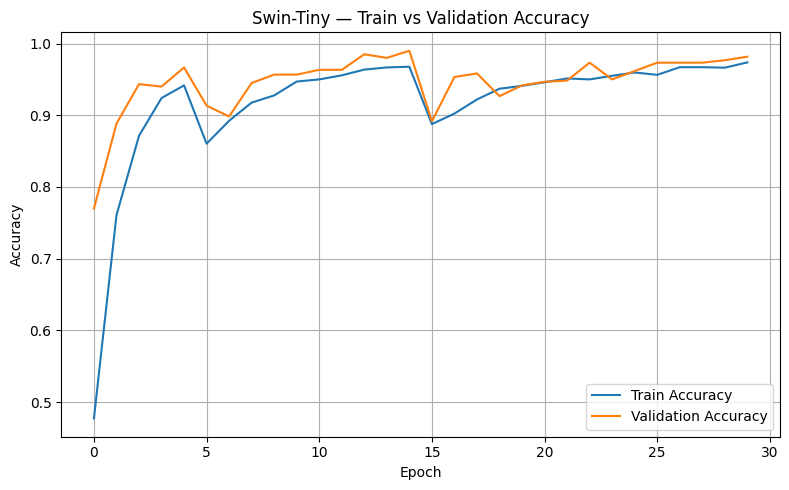

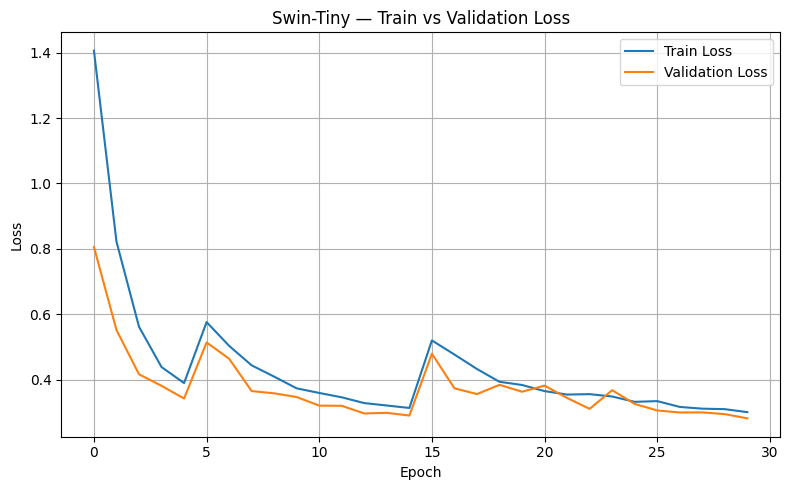


Final Testing on Test Set Only


Final Testing: 100%|██████████| 75/75 [00:02<00:00, 31.87it/s]



Final Test Classification Report:
              precision    recall  f1-score   support

       anger     0.7273    0.8000    0.7619       100
        fear     0.7917    0.9500    0.8636       100
         joy     0.8609    0.9900    0.9209       100
     natural     0.8750    0.9100    0.8922       100
     sadness     0.7656    0.4900    0.5976       100
    surprise     0.8851    0.7700    0.8235       100

    accuracy                         0.8183       600
   macro avg     0.8176    0.8183    0.8100       600
weighted avg     0.8176    0.8183    0.8100       600



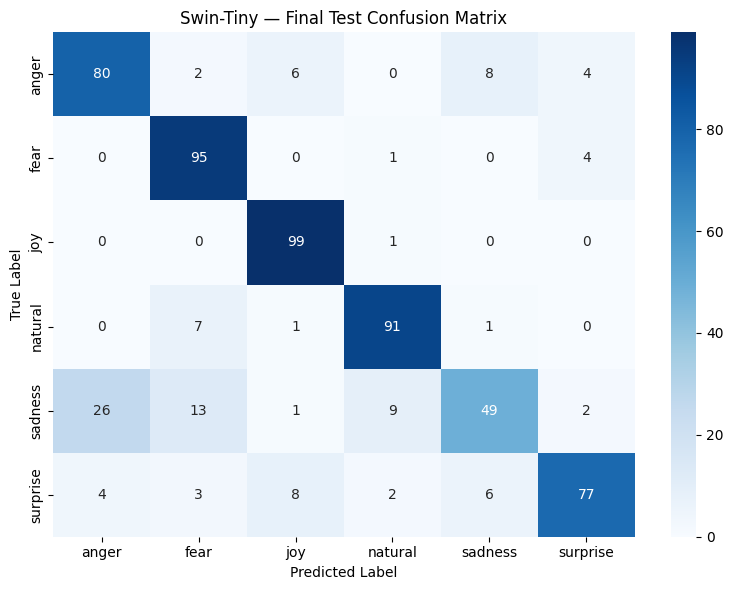


Swin-Tiny Final Result:


,model,batch_size,best_train_accuracy,final_test_accuracy,test_macro_precision,test_macro_recall,test_macro_f1,test_weighted_precision,test_weighted_recall,test_weighted_f1
0,swin_tiny,16,0.9737,0.8183,0.8176,0.8183,0.81,0.8176,0.8183,0.81



Saved files inside: /content/drive/MyDrive/Thesis Student/P3 /Group_3_Spring_2025/Update dataset/results/batch_16/swin_tiny


In [ ]:
def build_swin_tiny(num_classes):
    return timm.create_model("swin_tiny_patch4_window7_224", pretrained=True, num_classes=num_classes)

def train_swin_tiny(epochs=EPOCHS, lr=LR, model_folder_name="swin_tiny"):
    print("\n" + "=" * 90)
    print("Training Swin-Tiny | Batch Size: 4")
    print("=" * 90)

    model_output_dir = os.path.join(RESULTS_DIR_B16, model_folder_name)
    os.makedirs(model_output_dir, exist_ok=True)

    model     = build_swin_tiny(num_classes).to(device)
    criterion = nn.CrossEntropyLoss(label_smoothing=0.05)
    optimizer = optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-4)
    scheduler = optim.lr_scheduler.CosineAnnealingWarmRestarts(optimizer, T_0=5, T_mult=2, eta_min=1e-6)

    best_train_acc     = 0.0
    best_model_weights = copy.deepcopy(model.state_dict())
    history            = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}

    for epoch in range(epochs):
        start_time = time.time()
        model.train()
        train_loss_sum, train_correct, train_total = 0.0, 0, 0

        for images, labels in tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs} Training"):
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(images)
            loss    = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            _, predictions  = torch.max(outputs, 1)
            train_loss_sum += loss.item() * images.size(0)
            train_correct  += torch.sum(predictions == labels).item()
            train_total    += labels.size(0)

        train_loss = train_loss_sum / train_total
        train_acc  = train_correct  / train_total

        model.eval()
        val_loss_sum, val_correct, val_total = 0.0, 0, 0

        with torch.no_grad():
            for images, labels in tqdm(val_loader, desc=f"Epoch {epoch+1}/{epochs} Validation"):
                images, labels = images.to(device), labels.to(device)
                outputs        = model(images)
                loss           = criterion(outputs, labels)
                _, predictions = torch.max(outputs, 1)
                val_loss_sum  += loss.item() * images.size(0)
                val_correct   += torch.sum(predictions == labels).item()
                val_total     += labels.size(0)

        val_loss = val_loss_sum / val_total
        val_acc  = val_correct  / val_total
        scheduler.step()

        history["train_loss"].append(train_loss)
        history["train_acc"].append(train_acc)
        history["val_loss"].append(val_loss)
        history["val_acc"].append(val_acc)

        if train_acc > best_train_acc:
            best_train_acc     = train_acc
            best_model_weights = copy.deepcopy(model.state_dict())
            torch.save(model.state_dict(), os.path.join(model_output_dir, "best_model.pth"))

        print(
            f"Epoch {epoch+1}/{epochs} | "
            f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f} | "
            f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f} | "
            f"LR: {optimizer.param_groups[0]['lr']:.8f} | "
            f"Time: {time.time()-start_time:.1f}s"
        )

    model.load_state_dict(best_model_weights)
    pd.DataFrame(history).to_csv(os.path.join(model_output_dir, "training_history.csv"), index=False)

    plt.figure(figsize=(8, 5))
    plt.plot(history["train_acc"], label="Train Accuracy")
    plt.plot(history["val_acc"],   label="Validation Accuracy")
    plt.title("Swin-Tiny — Train vs Validation Accuracy")
    plt.xlabel("Epoch"); plt.ylabel("Accuracy"); plt.legend(); plt.grid(True); plt.tight_layout()
    plt.savefig(os.path.join(model_output_dir, "accuracy_curve.png")); plt.show()

    plt.figure(figsize=(8, 5))
    plt.plot(history["train_loss"], label="Train Loss")
    plt.plot(history["val_loss"],   label="Validation Loss")
    plt.title("Swin-Tiny — Train vs Validation Loss")
    plt.xlabel("Epoch"); plt.ylabel("Loss"); plt.legend(); plt.grid(True); plt.tight_layout()
    plt.savefig(os.path.join(model_output_dir, "loss_curve.png")); plt.show()

    print("\n" + "=" * 90)
    print("Final Testing on Test Set Only")
    print("=" * 90)

    model.eval()
    test_y_true, test_y_pred = [], []

    with torch.no_grad():
        for images, labels in tqdm(test_loader, desc="Final Testing"):
            images, labels = images.to(device), labels.to(device)
            outputs        = model(images)
            _, predictions = torch.max(torch.softmax(outputs, dim=1), 1)
            test_y_true.extend(labels.cpu().numpy())
            test_y_pred.extend(predictions.cpu().numpy())

    print("\nFinal Test Classification Report:")
    print(classification_report(test_y_true, test_y_pred, target_names=class_names, digits=4, zero_division=0))

    cm = confusion_matrix(test_y_true, test_y_pred)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt="d", xticklabels=class_names, yticklabels=class_names, cmap="Blues")
    plt.title("Swin-Tiny — Final Test Confusion Matrix")
    plt.xlabel("Predicted Label"); plt.ylabel("True Label"); plt.tight_layout()
    plt.savefig(os.path.join(model_output_dir, "confusion_matrix.png")); plt.show()

    report = classification_report(test_y_true, test_y_pred, target_names=class_names, output_dict=True, zero_division=0)
    pd.DataFrame(report).transpose().to_csv(os.path.join(model_output_dir, "test_classification_report.csv"))
    pd.DataFrame(cm, index=class_names, columns=class_names).to_csv(os.path.join(model_output_dir, "test_confusion_matrix.csv"))

    result = {
        "model":                   model_folder_name,
        "batch_size":              16,
        "best_train_accuracy":     round(best_train_acc, 4),
        "final_test_accuracy":     round(accuracy_score(test_y_true, test_y_pred), 4),
        "test_macro_precision":    round(report["macro avg"]["precision"], 4),
        "test_macro_recall":       round(report["macro avg"]["recall"], 4),
        "test_macro_f1":           round(report["macro avg"]["f1-score"], 4),
        "test_weighted_precision": round(report["weighted avg"]["precision"], 4),
        "test_weighted_recall":    round(report["weighted avg"]["recall"], 4),
        "test_weighted_f1":        round(report["weighted avg"]["f1-score"], 4)
    }

    result_df = pd.DataFrame([result])
    result_df.to_csv(os.path.join(model_output_dir, "swin_tiny_result_summary.csv"), index=False)
    print("\nSwin-Tiny Final Result:"); display(result_df)
    print("\nSaved files inside:", model_output_dir)
    return result, model

swin_tiny_result, swin_tiny_model = train_swin_tiny(
    epochs=30, lr=LR, model_folder_name="swin_tiny"
)

# Swin-Tiny — Improved (Freeze + Better Head + Regularization) = .80


Training Swin-Tiny (Frozen=1 stages) | Batch Size: 4
[Freezing] Patch embed + 1 stages frozen (229,590 parameters locked)

MODEL PARAMETER SUMMARY
Total Parameters     : 28,968,064
Trainable Parameters : 28,738,474
Frozen Parameters    : 229,590



Epoch 1/30 Validation: 100%|██████████| 75/75 [00:02<00:00, 32.61it/s]


Epoch 1/30 | Train Loss: 1.7234 | Train Acc: 0.2860 | Val Loss: 1.3785 | Val Acc: 0.5617 | LR: 0.00000978 | Time: 29.5s


Epoch 2/30 Validation: 100%|██████████| 75/75 [00:02<00:00, 31.90it/s]


Epoch 2/30 | Train Loss: 1.4627 | Train Acc: 0.4653 | Val Loss: 1.1006 | Val Acc: 0.7317 | LR: 0.00000914 | Time: 29.3s


...

Epoch 28/30 | Train Loss: 0.5967 | Train Acc: 0.9407 | Val Loss: 0.4746 | Val Acc: 0.9833 | LR: 0.00000122 | Time: 29.7s


Epoch 29/30 Validation: 100%|██████████| 75/75 [00:02<00:00, 31.09it/s]


Epoch 29/30 | Train Loss: 0.5849 | Train Acc: 0.9433 | Val Loss: 0.4669 | Val Acc: 0.9900 | LR: 0.00000106 | Time: 29.0s


Epoch 30/30 Validation: 100%|██████████| 75/75 [00:02<00:00, 31.41it/s]


Epoch 30/30 | Train Loss: 0.5842 | Train Acc: 0.9440 | Val Loss: 0.4742 | Val Acc: 0.9817 | LR: 0.00001000 | Time: 29.1s


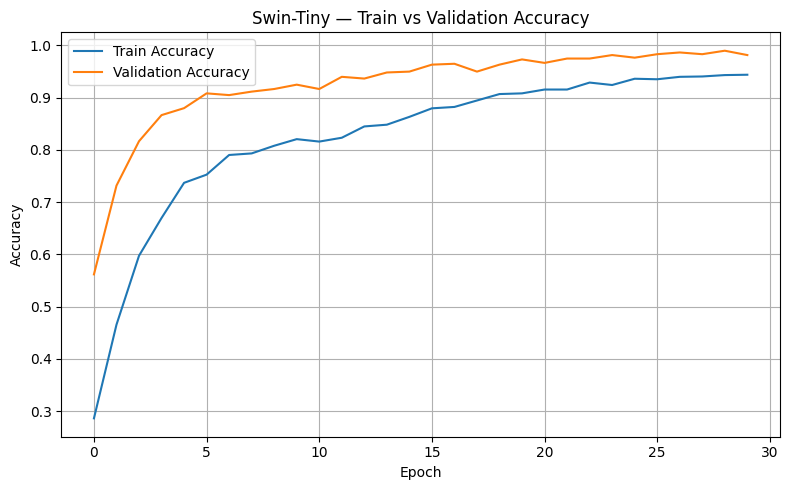

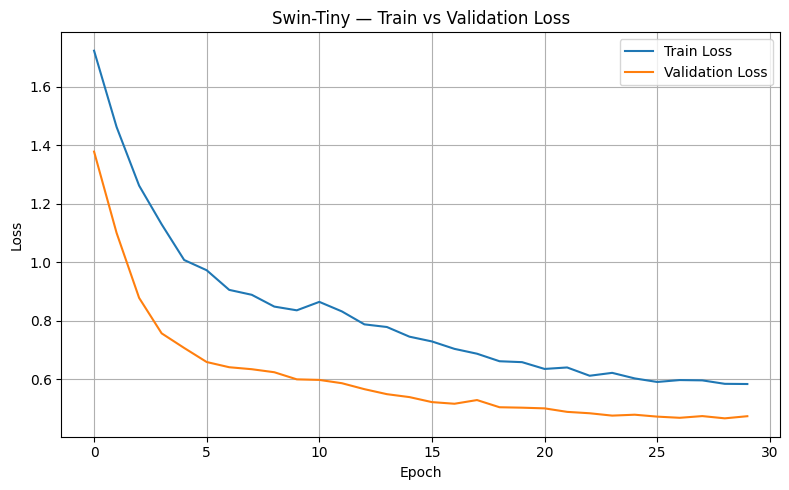


Final Testing on Test Set Only


Final Testing: 100%|██████████| 75/75 [00:02<00:00, 29.46it/s]



Final Test Classification Report:
              precision    recall  f1-score   support

       anger     0.7054    0.7900    0.7453       100
        fear     0.8103    0.9400    0.8704       100
         joy     0.8468    0.9400    0.8910       100
     natural     0.8411    0.9000    0.8696       100
     sadness     0.7333    0.4400    0.5500       100
    surprise     0.8404    0.7900    0.8144       100

    accuracy                         0.8000       600
   macro avg     0.7962    0.8000    0.7901       600
weighted avg     0.7962    0.8000    0.7901       600



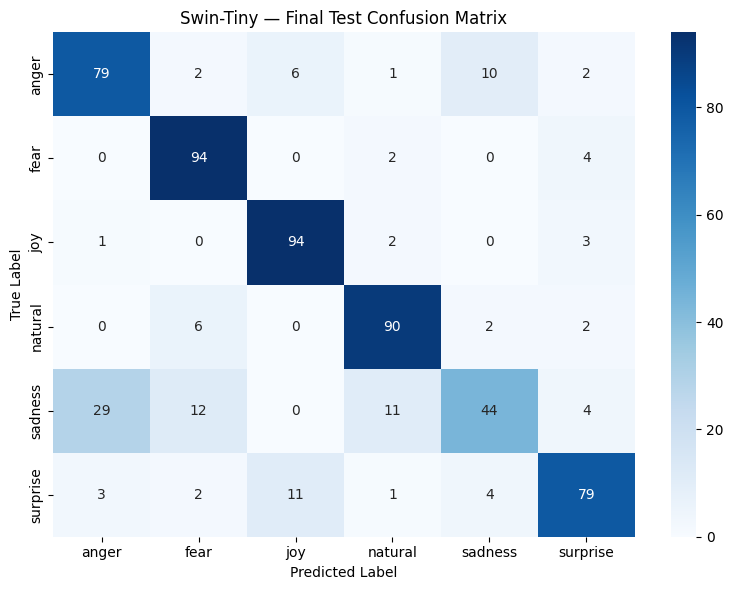


Swin-Tiny Final Result:


,model,batch_size,best_train_accuracy,final_test_accuracy,test_macro_precision,test_macro_recall,test_macro_f1,test_weighted_precision,test_weighted_recall,test_weighted_f1
0,swin_tiny,16,0.944,0.8,0.7962,0.8,0.7901,0.7962,0.8,0.7901



Saved files inside: /content/drive/MyDrive/Thesis Student/P3 /Group_3_Spring_2025/Update dataset/results/batch_16/swin_tiny


In [ ]:
# ============================================================
# Swin-Tiny — Improved (Freeze + Better Head + Regularization)
# ============================================================

def build_swin_tiny_improved(num_classes, freeze_stages=2):

    backbone = timm.create_model(
        "swin_tiny_patch4_window7_224",
        pretrained=True,
        num_classes=0          # remove built-in head
    )

    # ----------------------------------------------------------
    # Freeze: patch embedding + first N Swin stages
    # Swin-Tiny has 4 stages; freezing 0-1 locks generic features
    # ----------------------------------------------------------
    # Freeze patch embedding
    for param in backbone.patch_embed.parameters():
        param.requires_grad = False

    # Freeze first N stages
    for stage_idx, layer in enumerate(backbone.layers):
        if stage_idx < freeze_stages:
            for param in layer.parameters():
                param.requires_grad = False

    frozen = sum(p.numel() for p in backbone.parameters() if not p.requires_grad)
    print(f"[Freezing] Patch embed + {freeze_stages} stages frozen ({frozen:,} parameters locked)")

    return backbone


class SwinTinyClassifier(nn.Module):

    def __init__(self, num_classes, freeze_stages=2):
        super(SwinTinyClassifier, self).__init__()

        self.backbone = build_swin_tiny_improved(num_classes, freeze_stages)
        in_features   = self.backbone.num_features   # 768 for swin_tiny

        # ----------------------------------------------------------
        # Improved classifier head — wider + deeper + stronger dropout
        # ----------------------------------------------------------
        self.classifier = nn.Sequential(
            # Block 1
            nn.Linear(in_features, 1024),
            nn.BatchNorm1d(1024),
            nn.GELU(),
            nn.Dropout(0.5),

            # Block 2
            nn.Linear(1024, 512),
            nn.BatchNorm1d(512),
            nn.GELU(),
            nn.Dropout(0.4),

            # Block 3 (new)
            nn.Linear(512, 256),
            nn.BatchNorm1d(256),
            nn.GELU(),
            nn.Dropout(0.3),

            # Output
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        features = self.backbone(x)
        return self.classifier(features)


def print_parameter_summary(model):
    total     = sum(p.numel() for p in model.parameters())
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    frozen    = total - trainable

    print("\n===================================")
    print("MODEL PARAMETER SUMMARY")
    print("===================================")
    print(f"Total Parameters     : {total:,}")
    print(f"Trainable Parameters : {trainable:,}")
    print(f"Frozen Parameters    : {frozen:,}")
    print("===================================\n")


def train_swin_tiny(
    epochs=EPOCHS,
    lr=LR,
    model_folder_name="swin_tiny",
    freeze_stages=2          # tune: 0 = no freeze, 4 = freeze all stages
):
    print("\n" + "=" * 90)
    print(f"Training Swin-Tiny (Frozen={freeze_stages} stages) | Batch Size: 4")
    print("=" * 90)

    model_output_dir = os.path.join(RESULTS_DIR_B16, model_folder_name)
    os.makedirs(model_output_dir, exist_ok=True)

    model = SwinTinyClassifier(num_classes, freeze_stages=freeze_stages).to(device)
    print_parameter_summary(model)

    # ----------------------------------------------------------
    # Higher label_smoothing to soften overconfident predictions
    # ----------------------------------------------------------
    criterion = nn.CrossEntropyLoss(
        weight=class_weights_tensor.to(device),   # class-balanced loss
        label_smoothing=0.1                        # ↑ from 0.05
    )

    # ----------------------------------------------------------
    # Differential learning rates:
    #   backbone unfrozen layers → small lr (fine-tune gently)
    #   classifier head          → full lr  (learn aggressively)
    # ----------------------------------------------------------
    backbone_params   = [p for p in model.backbone.parameters()    if p.requires_grad]
    classifier_params = [p for p in model.classifier.parameters()  if p.requires_grad]

    optimizer = optim.AdamW([
        {"params": backbone_params,   "lr": lr * 0.1},   # e.g. 1e-5
        {"params": classifier_params, "lr": lr},          # e.g. 1e-4
    ], weight_decay=2e-4)                                 # ↑ stronger L2

    scheduler = optim.lr_scheduler.CosineAnnealingWarmRestarts(
        optimizer, T_0=10, T_mult=2, eta_min=1e-6
    )

    scaler = torch.amp.GradScaler("cuda")

    best_train_acc     = 0.0
    best_model_weights = copy.deepcopy(model.state_dict())
    history            = {"train_loss": [], "train_acc": [],
                          "val_loss":   [], "val_acc":   []}

    # ========================================================
    # Training Loop
    # ========================================================

    for epoch in range(epochs):
        start_time = time.time()
        model.train()
        train_loss_sum, train_correct, train_total = 0.0, 0, 0

        for images, labels in tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs} Training"):

            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()

            with torch.amp.autocast("cuda"):
                outputs = model(images)
                loss    = criterion(outputs, labels)

            scaler.scale(loss).backward()
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            scaler.step(optimizer)
            scaler.update()

            _, predictions  = torch.max(outputs, 1)
            train_loss_sum += loss.item() * images.size(0)
            train_correct  += torch.sum(predictions == labels).item()
            train_total    += labels.size(0)

        train_loss = train_loss_sum / train_total
        train_acc  = train_correct  / train_total

        # ====================================================
        # Validation
        # ====================================================

        model.eval()
        val_loss_sum, val_correct, val_total = 0.0, 0, 0

        with torch.no_grad():
            for images, labels in tqdm(val_loader, desc=f"Epoch {epoch+1}/{epochs} Validation"):

                images, labels = images.to(device), labels.to(device)

                with torch.amp.autocast("cuda"):
                    outputs = model(images)
                    loss    = criterion(outputs, labels)

                _, predictions = torch.max(outputs, 1)
                val_loss_sum  += loss.item() * images.size(0)
                val_correct   += torch.sum(predictions == labels).item()
                val_total     += labels.size(0)

        val_loss = val_loss_sum / val_total
        val_acc  = val_correct  / val_total
        scheduler.step()

        history["train_loss"].append(train_loss)
        history["train_acc"].append(train_acc)
        history["val_loss"].append(val_loss)
        history["val_acc"].append(val_acc)

        if train_acc > best_train_acc:
            best_train_acc     = train_acc
            best_model_weights = copy.deepcopy(model.state_dict())
            torch.save(model.state_dict(),
                       os.path.join(model_output_dir, "best_model.pth"))

        print(
            f"Epoch {epoch+1}/{epochs} | "
            f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f} | "
            f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f} | "
            f"LR: {optimizer.param_groups[0]['lr']:.8f} | "
            f"Time: {time.time()-start_time:.1f}s"
        )

    # ========================================================
    # Load Best Model & Test
    # ========================================================

    model.load_state_dict(best_model_weights)
    pd.DataFrame(history).to_csv(
        os.path.join(model_output_dir, "training_history.csv"), index=False
    )

    # ====================================================
    # Training Curves
    # ====================================================

    plt.figure(figsize=(8, 5))
    plt.plot(history["train_acc"], label="Train Accuracy")
    plt.plot(history["val_acc"],   label="Validation Accuracy")
    plt.title("Swin-Tiny — Train vs Validation Accuracy")
    plt.xlabel("Epoch"); plt.ylabel("Accuracy")
    plt.legend(); plt.grid(True); plt.tight_layout()
    plt.savefig(os.path.join(model_output_dir, "accuracy_curve.png")); plt.show()

    plt.figure(figsize=(8, 5))
    plt.plot(history["train_loss"], label="Train Loss")
    plt.plot(history["val_loss"],   label="Validation Loss")
    plt.title("Swin-Tiny — Train vs Validation Loss")
    plt.xlabel("Epoch"); plt.ylabel("Loss")
    plt.legend(); plt.grid(True); plt.tight_layout()
    plt.savefig(os.path.join(model_output_dir, "loss_curve.png")); plt.show()

    # ====================================================
    # Final Test
    # ====================================================

    print("\n" + "=" * 90)
    print("Final Testing on Test Set Only")
    print("=" * 90)

    model.eval()
    test_y_true, test_y_pred = [], []

    with torch.no_grad():
        for images, labels in tqdm(test_loader, desc="Final Testing"):
            images, labels = images.to(device), labels.to(device)
            outputs        = model(images)
            _, predictions = torch.max(torch.softmax(outputs, dim=1), 1)
            test_y_true.extend(labels.cpu().numpy())
            test_y_pred.extend(predictions.cpu().numpy())

    print("\nFinal Test Classification Report:")
    print(classification_report(
        test_y_true, test_y_pred,
        target_names=class_names, digits=4, zero_division=0
    ))

    cm = confusion_matrix(test_y_true, test_y_pred)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt="d",
                xticklabels=class_names, yticklabels=class_names, cmap="Blues")
    plt.title("Swin-Tiny — Final Test Confusion Matrix")
    plt.xlabel("Predicted Label"); plt.ylabel("True Label")
    plt.tight_layout()
    plt.savefig(os.path.join(model_output_dir, "confusion_matrix.png")); plt.show()

    report = classification_report(
        test_y_true, test_y_pred,
        target_names=class_names, output_dict=True, zero_division=0
    )

    pd.DataFrame(report).transpose().to_csv(
        os.path.join(model_output_dir, "test_classification_report.csv")
    )
    pd.DataFrame(cm, index=class_names, columns=class_names).to_csv(
        os.path.join(model_output_dir, "test_confusion_matrix.csv")
    )

    result = {
        "model":                   model_folder_name,
        "batch_size":              16,
        "best_train_accuracy":     round(best_train_acc, 4),
        "final_test_accuracy":     round(accuracy_score(test_y_true, test_y_pred), 4),
        "test_macro_precision":    round(report["macro avg"]["precision"], 4),
        "test_macro_recall":       round(report["macro avg"]["recall"], 4),
        "test_macro_f1":           round(report["macro avg"]["f1-score"], 4),
        "test_weighted_precision": round(report["weighted avg"]["precision"], 4),
        "test_weighted_recall":    round(report["weighted avg"]["recall"], 4),
        "test_weighted_f1":        round(report["weighted avg"]["f1-score"], 4)
    }

    result_df = pd.DataFrame([result])
    result_df.to_csv(
        os.path.join(model_output_dir, "swin_tiny_result_summary.csv"), index=False
    )
    print("\nSwin-Tiny Final Result:"); display(result_df)
    print("\nSaved files inside:", model_output_dir)

    return result, model


# ============================================================
# Run
# ============================================================

swin_tiny_result, swin_tiny_model = train_swin_tiny(
    epochs=EPOCHS,
    lr=LR,
    model_folder_name="swin_tiny",
    freeze_stages=1        # freeze patch_embed + stages 0 & 1
)

# Hybrid Swin-Tiny + ResNet-152(16) = 0.8017

Classes          : ['anger', 'fear', 'joy', 'natural', 'sadness', 'surprise']
Number of classes: 6
Train images     : 2400
Validation images: 600
Test images      : 600
Total training images (train + val): 3000

Training ASD-SwinResFusionNet (Swin-Tiny + ResNet-152) | Batch Size: 8


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model.safetensors:   0%|          | 0.00/114M [00:00<?, ?B/s]

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet152_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet152_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/resnet152-394f9c45.pth" to /root/.cache/torch/hub/checkpoints/resnet152-394f9c45.pth


...

Epoch 28/30 | Train Loss: 0.0215 | Train Acc: 0.9750 | Val Loss: 0.0143 | Val Acc: 0.9850 | Val F1: 0.9850 | Val Prec: 0.9850 | Val Recall: 0.9850 | LR: 3.42e-06 | Time: 75.1s


Epoch 29/30 Validation: 100%|██████████| 75/75 [00:03<00:00, 19.58it/s]


Epoch 29/30 | Train Loss: 0.0193 | Train Acc: 0.9777 | Val Loss: 0.0112 | Val Acc: 0.9850 | Val F1: 0.9850 | Val Prec: 0.9850 | Val Recall: 0.9850 | LR: 1.61e-06 | Time: 69.1s


Epoch 30/30 Validation: 100%|██████████| 75/75 [00:03<00:00, 20.25it/s]


Epoch 30/30 | Train Loss: 0.0162 | Train Acc: 0.9800 | Val Loss: 0.0133 | Val Acc: 0.9850 | Val F1: 0.9849 | Val Prec: 0.9853 | Val Recall: 0.9850 | LR: 1.00e-04 | Time: 68.7s


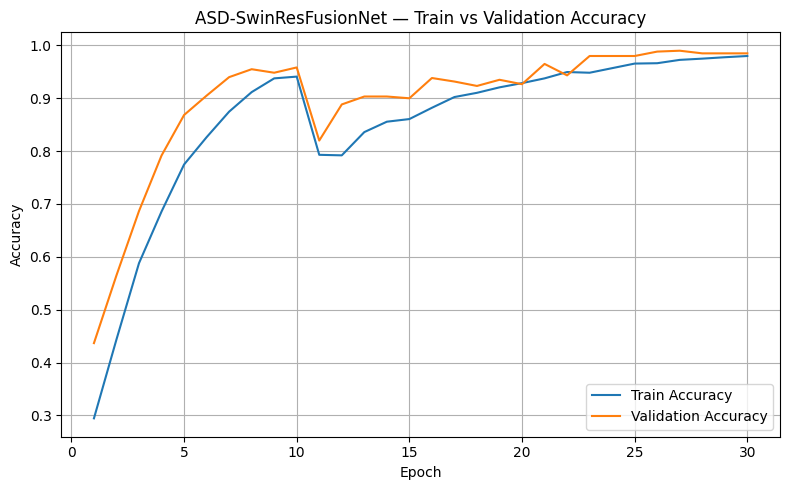

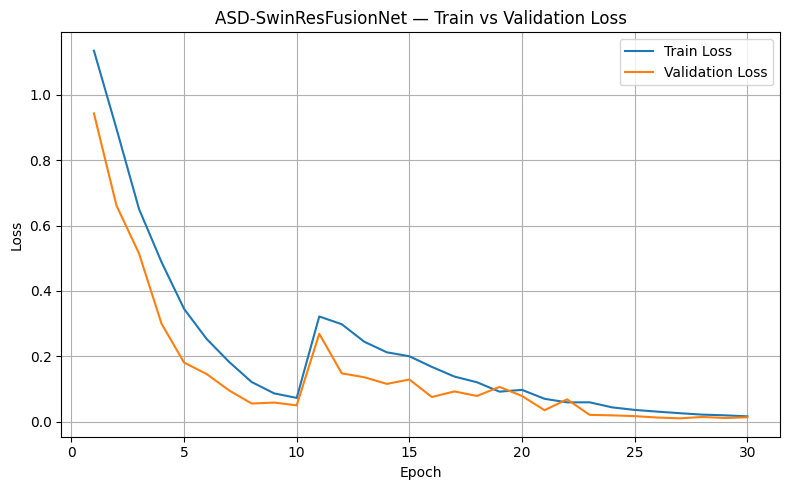

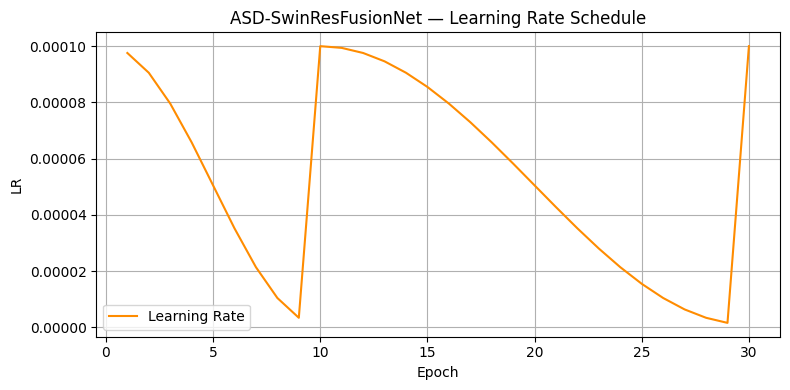


Final Testing on Test Set Only


Final Testing: 100%|██████████| 75/75 [03:46<00:00,  3.02s/it]



Final Test Classification Report:
              precision    recall  f1-score   support

       anger     0.7143    0.8000    0.7547       100
        fear     0.8125    0.9100    0.8585       100
         joy     0.8818    0.9700    0.9238       100
     natural     0.8142    0.9200    0.8638       100
     sadness     0.7091    0.3900    0.5032       100
    surprise     0.8367    0.8200    0.8283       100

    accuracy                         0.8017       600
   macro avg     0.7948    0.8017    0.7887       600
weighted avg     0.7948    0.8017    0.7887       600



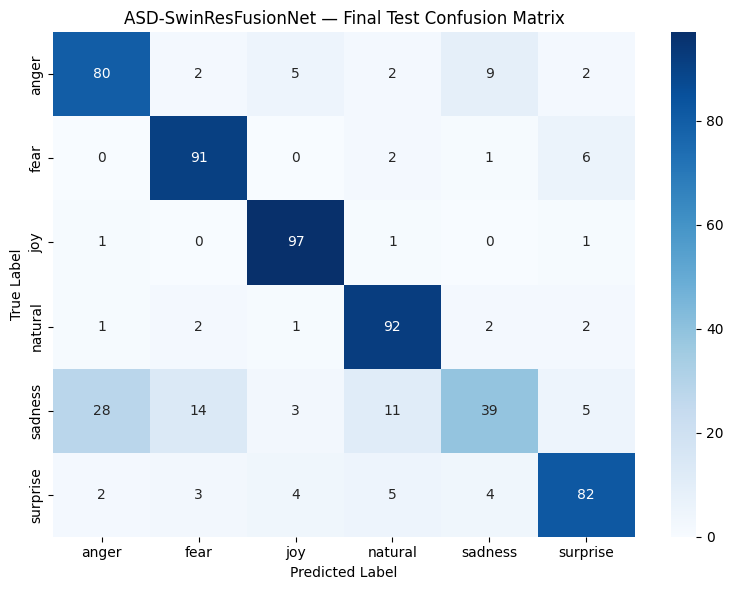


ASD-SwinResFusionNet Final Result:


,model,batch_size,total_parameters,trainable_parameters,best_val_accuracy,final_test_accuracy,test_macro_precision,test_macro_recall,test_macro_f1,test_weighted_precision,test_weighted_recall,test_weighted_f1
0,asd_swinresfusionnet,8,88883968,88883968,0.99,0.8017,0.7948,0.8017,0.7887,0.7948,0.8017,0.7887



Best validation model saved to : /content/drive/MyDrive/Thesis Student/P3 /Group_3_Spring_2025/Update dataset/results/batch_16/asd_swinresfusionnet/best_val_model.pth
All files saved inside         : /content/drive/MyDrive/Thesis Student/P3 /Group_3_Spring_2025/Update dataset/results/batch_16/asd_swinresfusionnet


In [ ]:
# ============================================================
# ASD-SWINRESFUSIONNET
# Hybrid Swin-Tiny + ResNet-152
# Autism Child Emotion Detection
# ============================================================

import os
import gc
import copy
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from tqdm import tqdm

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F

import timm

from torchvision import datasets, models
from torch.utils.data import DataLoader, ConcatDataset
from sklearn.metrics import (
    accuracy_score, classification_report,
    confusion_matrix, f1_score,
    precision_score, recall_score
)
from sklearn.utils.class_weight import compute_class_weight

# ============================================================
# Memory Optimization
# ============================================================

os.environ["PYTORCH_ALLOC_CONF"] = "expandable_segments:True"
torch.cuda.empty_cache()
gc.collect()

# ============================================================
# Settings
# ============================================================

RESULTS_DIR_B16 = os.path.join(PROJECT_DIR, "results", "batch_16")
os.makedirs(RESULTS_DIR_B16, exist_ok=True)

# ============================================================
# Datasets
# ============================================================

train_dataset = datasets.ImageFolder(AUG_TRAIN_DIR, transform=transform)
val_dataset   = datasets.ImageFolder(AUG_VAL_DIR,   transform=transform)
test_dataset  = datasets.ImageFolder(AUG_TEST_DIR,  transform=transform)

if train_dataset.classes != val_dataset.classes:
    raise ValueError("Train and validation class names do not match!")
if train_dataset.classes != test_dataset.classes:
    raise ValueError("Train and test class names do not match!")

class_names = train_dataset.classes
num_classes = len(class_names)

print("Classes          :", class_names)
print("Number of classes:", num_classes)
print("Train images     :", len(train_dataset))
print("Validation images:", len(val_dataset))
print("Test images      :", len(test_dataset))

combined_train_dataset = ConcatDataset([train_dataset, val_dataset])
print("Total training images (train + val):", len(combined_train_dataset))

train_loader = DataLoader(combined_train_dataset, batch_size=8, shuffle=True,
                          num_workers=NUM_WORKERS, pin_memory=True)
val_loader   = DataLoader(val_dataset,  batch_size=8, shuffle=False,
                          num_workers=NUM_WORKERS, pin_memory=True)
test_loader  = DataLoader(test_dataset, batch_size=8, shuffle=False,
                          num_workers=NUM_WORKERS, pin_memory=True)

# ============================================================
# Class Weights
# ============================================================

_train_labels        = [label for _, label in train_dataset.samples]
_class_weights_np    = compute_class_weight(
    class_weight="balanced",
    classes=np.arange(num_classes),
    y=_train_labels
)
class_weights_tensor = torch.tensor(_class_weights_np, dtype=torch.float)

# ============================================================
# Helper — Parameter Count
# ============================================================

def count_parameters(model):
    total     = sum(p.numel() for p in model.parameters())
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    frozen    = total - trainable
    print("\n===================================")
    print("MODEL PARAMETER SUMMARY")
    print("===================================")
    print(f"Total Parameters     : {total:,}")
    print(f"Trainable Parameters : {trainable:,}")
    print(f"Frozen Parameters    : {frozen:,}")
    print("===================================\n")
    return total, trainable

# ============================================================
# SE Block
# ============================================================

class SEBlock(nn.Module):

    def __init__(self, channels, reduction=16):
        super().__init__()
        hidden   = max(channels // reduction, 8)
        self.fc  = nn.Sequential(
            nn.Linear(channels, hidden),
            nn.ReLU(inplace=True),
            nn.Linear(hidden, channels),
            nn.Sigmoid()
        )

    def forward(self, x):
        return x * self.fc(x)

# ============================================================
# Attention Fusion
# ============================================================

class AttentionFusion(nn.Module):

    def __init__(self, dim):
        super().__init__()
        self.attn = nn.Sequential(
            nn.Linear(dim * 2, dim),
            nn.GELU(),
            nn.Dropout(0.2),
            nn.Linear(dim, dim * 2),
            nn.Sigmoid()
        )

    def forward(self, x1, x2):
        fused    = torch.cat([x1, x2], dim=1)
        weights  = self.attn(fused)
        w1, w2   = torch.chunk(weights, 2, dim=1)
        return torch.cat([x1 * w1, x2 * w2], dim=1)

# ============================================================
# Focal Loss
# ============================================================

class FocalLoss(nn.Module):

    def __init__(self, gamma=2.0, reduction="mean"):
        super().__init__()
        self.gamma     = gamma
        self.reduction = reduction

    def forward(self, inputs, targets):
        ce_loss    = F.cross_entropy(inputs, targets, reduction="none")
        pt         = torch.exp(-ce_loss)
        focal_loss = ((1 - pt) ** self.gamma) * ce_loss
        return focal_loss.mean() if self.reduction == "mean" else focal_loss.sum()

# ============================================================
# ASD-SwinResFusionNet
# ============================================================

class ASDSwinResFusionNet(nn.Module):

    def __init__(self, num_classes, pretrained=True):
        super().__init__()

        # ── Swin-Tiny branch ──────────────────────────────────
        self.swintiny  = timm.create_model(
            "swin_tiny_patch4_window7_224",
            pretrained=pretrained,
            num_classes=0,
            global_pool="avg"
        )
        swin_dim = self.swintiny.num_features          # 768

        # ── ResNet-152 branch ─────────────────────────────────
        resnet         = models.resnet152(pretrained=pretrained)
        resnet.fc      = nn.Identity()                 # remove final FC layer
        self.resnet152 = resnet
        res_dim        = 2048                          # ResNet-152 output dim

        # ── Feature refinement ────────────────────────────────
        self.swin_branch = nn.Sequential(
            nn.Linear(swin_dim, 512),
            nn.LayerNorm(512),
            nn.GELU(),
            nn.Dropout(0.3)
        )

        self.resnet_branch = nn.Sequential(
            nn.Linear(res_dim, 512),
            nn.LayerNorm(512),
            nn.GELU(),
            nn.Dropout(0.3)
        )

        # ── SE attention ──────────────────────────────────────
        self.swin_se   = SEBlock(512)
        self.resnet_se = SEBlock(512)

        # ── Attention fusion ──────────────────────────────────
        self.fusion = AttentionFusion(512)

        # ── Classifier head ───────────────────────────────────
        self.classifier = nn.Sequential(
            nn.Linear(1024, 512),
            nn.LayerNorm(512),
            nn.GELU(),
            nn.Dropout(0.4),
            nn.Linear(512, 256),
            nn.LayerNorm(256),
            nn.GELU(),
            nn.Dropout(0.3),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        swin_feat   = self.swin_branch(self.swintiny(x))
        swin_feat   = self.swin_se(swin_feat)

        res_feat    = self.resnet_branch(self.resnet152(x))
        res_feat    = self.resnet_se(res_feat)

        fused = self.fusion(swin_feat, res_feat)
        return self.classifier(fused)

# ============================================================
# Training Function
# ============================================================

def train_asd_swinresfusionnet(
    epochs=EPOCHS,
    lr=LR,
    model_folder_name="asd_swinresfusionnet"
):
    print("\n" + "=" * 90)
    print("Training ASD-SwinResFusionNet (Swin-Tiny + ResNet-152) | Batch Size: 8")
    print("=" * 90)

    model_output_dir = os.path.join(RESULTS_DIR_B16, model_folder_name)
    os.makedirs(model_output_dir, exist_ok=True)

    model = ASDSwinResFusionNet(num_classes=num_classes).to(device)

    # ── 1. Parameter summary ──────────────────────────────────
    total_params, trainable_params = count_parameters(model)

    criterion = FocalLoss(gamma=2.0)

    optimizer = optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-4)
    scheduler = optim.lr_scheduler.CosineAnnealingWarmRestarts(
        optimizer, T_0=10, T_mult=2, eta_min=1e-6
    )
    scaler = torch.amp.GradScaler("cuda")

    # ── 2. Track best validation accuracy ─────────────────────
    best_val_acc       = 0.0
    best_model_weights = copy.deepcopy(model.state_dict())
    best_val_path      = os.path.join(model_output_dir, "best_val_model.pth")

    history = {
        "train_loss": [], "train_acc": [],
        "val_loss":   [], "val_acc":   [],
        "lr":         []
    }

    # ============================================================
    # Training Loop
    # ============================================================

    for epoch in range(epochs):
        start_time = time.time()
        model.train()
        train_loss_sum, train_correct, train_total = 0.0, 0, 0

        for images, labels in tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs} Training"):
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()

            with torch.amp.autocast("cuda"):
                outputs = model(images)
                loss    = criterion(outputs, labels)

            scaler.scale(loss).backward()
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            scaler.step(optimizer)
            scaler.update()

            _, predictions  = torch.max(outputs, 1)
            train_loss_sum += loss.item() * images.size(0)
            train_correct  += torch.sum(predictions == labels).item()
            train_total    += labels.size(0)

        train_loss = train_loss_sum / train_total
        train_acc  = train_correct  / train_total

        # ── Validation ────────────────────────────────────────
        model.eval()
        val_loss_sum, val_correct, val_total = 0.0, 0, 0
        val_preds_all, val_labels_all = [], []

        with torch.no_grad():
            for images, labels in tqdm(val_loader, desc=f"Epoch {epoch+1}/{epochs} Validation"):
                images, labels = images.to(device), labels.to(device)

                with torch.amp.autocast("cuda"):
                    outputs = model(images)
                    loss    = criterion(outputs, labels)

                _, predictions = torch.max(outputs, 1)
                val_loss_sum  += loss.item() * images.size(0)
                val_correct   += torch.sum(predictions == labels).item()
                val_total     += labels.size(0)
                val_preds_all.extend(predictions.cpu().numpy())
                val_labels_all.extend(labels.cpu().numpy())

        val_loss   = val_loss_sum / val_total
        val_acc    = val_correct  / val_total
        scheduler.step()

        current_lr  = optimizer.param_groups[0]['lr']
        val_f1      = f1_score(val_labels_all, val_preds_all, average="weighted", zero_division=0)
        val_prec    = precision_score(val_labels_all, val_preds_all, average="weighted", zero_division=0)
        val_recall  = recall_score(val_labels_all, val_preds_all, average="weighted", zero_division=0)

        history["train_loss"].append(train_loss)
        history["train_acc"].append(train_acc)
        history["val_loss"].append(val_loss)
        history["val_acc"].append(val_acc)
        history["lr"].append(current_lr)

        # ── Save best validation weights ──────────────────────
        if val_acc > best_val_acc:
            best_val_acc       = val_acc
            best_model_weights = copy.deepcopy(model.state_dict())
            torch.save(model.state_dict(), best_val_path)
            saved_flag = "  ✓ best val saved"
        else:
            saved_flag = ""

        print(
            f"Epoch {epoch+1}/{epochs} | "
            f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f} | "
            f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f} | "
            f"Val F1: {val_f1:.4f} | Val Prec: {val_prec:.4f} | Val Recall: {val_recall:.4f} | "
            f"LR: {current_lr:.2e} | Time: {time.time()-start_time:.1f}s"
            f"{saved_flag}"
        )

    # ── Load best weights ─────────────────────────────────────
    model.load_state_dict(best_model_weights)
    pd.DataFrame(history).to_csv(os.path.join(model_output_dir, "training_history.csv"), index=False)

    epochs_range = range(1, epochs + 1)

    # ── 3a. Accuracy curve ────────────────────────────────────
    plt.figure(figsize=(8, 5))
    plt.plot(epochs_range, history["train_acc"], label="Train Accuracy")
    plt.plot(epochs_range, history["val_acc"],   label="Validation Accuracy")
    plt.title("ASD-SwinResFusionNet — Train vs Validation Accuracy")
    plt.xlabel("Epoch"); plt.ylabel("Accuracy"); plt.legend(); plt.grid(True); plt.tight_layout()
    plt.savefig(os.path.join(model_output_dir, "accuracy_curve.png")); plt.show()

    # ── 3b. Loss curve ────────────────────────────────────────
    plt.figure(figsize=(8, 5))
    plt.plot(epochs_range, history["train_loss"], label="Train Loss")
    plt.plot(epochs_range, history["val_loss"],   label="Validation Loss")
    plt.title("ASD-SwinResFusionNet — Train vs Validation Loss")
    plt.xlabel("Epoch"); plt.ylabel("Loss"); plt.legend(); plt.grid(True); plt.tight_layout()
    plt.savefig(os.path.join(model_output_dir, "loss_curve.png")); plt.show()

    # ── 3c. Learning-rate curve ───────────────────────────────
    plt.figure(figsize=(8, 4))
    plt.plot(epochs_range, history["lr"], color="darkorange", label="Learning Rate")
    plt.title("ASD-SwinResFusionNet — Learning Rate Schedule")
    plt.xlabel("Epoch"); plt.ylabel("LR"); plt.legend(); plt.grid(True); plt.tight_layout()
    plt.savefig(os.path.join(model_output_dir, "lr_curve.png")); plt.show()

    # ── Final test ────────────────────────────────────────────
    print("\n" + "=" * 90)
    print("Final Testing on Test Set Only")
    print("=" * 90)

    model.eval()
    test_y_true, test_y_pred = [], []

    with torch.no_grad():
        for images, labels in tqdm(test_loader, desc="Final Testing"):
            images = images.to(device)
            with torch.amp.autocast("cuda"):
                outputs = model(images)
            _, predictions = torch.max(torch.softmax(outputs, dim=1), 1)
            test_y_true.extend(labels.numpy())
            test_y_pred.extend(predictions.cpu().numpy())

    print("\nFinal Test Classification Report:")
    print(classification_report(test_y_true, test_y_pred,
                                 target_names=class_names, digits=4, zero_division=0))

    cm = confusion_matrix(test_y_true, test_y_pred)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt="d", xticklabels=class_names,
                yticklabels=class_names, cmap="Blues")
    plt.title("ASD-SwinResFusionNet — Final Test Confusion Matrix")
    plt.xlabel("Predicted Label"); plt.ylabel("True Label"); plt.tight_layout()
    plt.savefig(os.path.join(model_output_dir, "confusion_matrix.png")); plt.show()

    report = classification_report(test_y_true, test_y_pred,
                                    target_names=class_names,
                                    output_dict=True, zero_division=0)
    pd.DataFrame(report).transpose().to_csv(
        os.path.join(model_output_dir, "test_classification_report.csv"))
    pd.DataFrame(cm, index=class_names, columns=class_names).to_csv(
        os.path.join(model_output_dir, "test_confusion_matrix.csv"))

    result = {
        "model":                   model_folder_name,
        "batch_size":              8,
        "total_parameters":        total_params,
        "trainable_parameters":    trainable_params,
        "best_val_accuracy":       round(best_val_acc, 4),
        "final_test_accuracy":     round(accuracy_score(test_y_true, test_y_pred), 4),
        "test_macro_precision":    round(report["macro avg"]["precision"], 4),
        "test_macro_recall":       round(report["macro avg"]["recall"], 4),
        "test_macro_f1":           round(report["macro avg"]["f1-score"], 4),
        "test_weighted_precision": round(report["weighted avg"]["precision"], 4),
        "test_weighted_recall":    round(report["weighted avg"]["recall"], 4),
        "test_weighted_f1":        round(report["weighted avg"]["f1-score"], 4)
    }

    result_df = pd.DataFrame([result])
    result_df.to_csv(os.path.join(model_output_dir, "asd_swinresfusionnet_result_summary.csv"), index=False)
    print("\nASD-SwinResFusionNet Final Result:"); display(result_df)
    print(f"\nBest validation model saved to : {best_val_path}")
    print("All files saved inside         :", model_output_dir)
    return result, model

# ============================================================
# Run
# ============================================================

asd_swinresfusionnet_result, asd_swinresfusionnet_model = train_asd_swinresfusionnet(
    epochs=EPOCHS,
    lr=LR,
    model_folder_name="asd_swinresfusionnet"
)

# Mobilenetv2= 0.7850

Classes          : ['anger', 'fear', 'joy', 'natural', 'sadness', 'surprise']
Number of classes: 6
Train images     : 2400
Validation images: 600
Test images      : 600
Total training images (train + val): 3000

Training MobileNetV2 | Batch Size: 4
Downloading: "https://download.pytorch.org/models/mobilenet_v2-b0353104.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v2-b0353104.pth


100%|██████████| 13.6M/13.6M [00:00<00:00, 135MB/s]



Model Parameter Summary:
  Total parameters    : 2,231,558
  Trainable parameters: 2,231,558


Epoch 1/30 Validation: 100%|██████████| 150/150 [00:02<00:00, 66.02it/s]


Epoch 1/30 | Train Loss: 1.5168 | Train Acc: 0.4213 | Val Loss: 0.9515 | Val Acc: 0.6950 | LR: 0.00009055 | Time: 603.6s  ✓ best val saved


...

Epoch 28/30 | Train Loss: 0.3884 | Train Acc: 0.9540 | Val Loss: 0.3486 | Val Acc: 0.9650 | LR: 0.00002803 | Time: 22.7s


Epoch 29/30 Validation: 100%|██████████| 150/150 [00:02<00:00, 63.42it/s]


Epoch 29/30 | Train Loss: 0.3769 | Train Acc: 0.9557 | Val Loss: 0.3431 | Val Acc: 0.9700 | LR: 0.00002140 | Time: 23.5s  ✓ best val saved


Epoch 30/30 Validation: 100%|██████████| 150/150 [00:02<00:00, 63.16it/s]


Epoch 30/30 | Train Loss: 0.3656 | Train Acc: 0.9617 | Val Loss: 0.3299 | Val Acc: 0.9700 | LR: 0.00001550 | Time: 22.4s


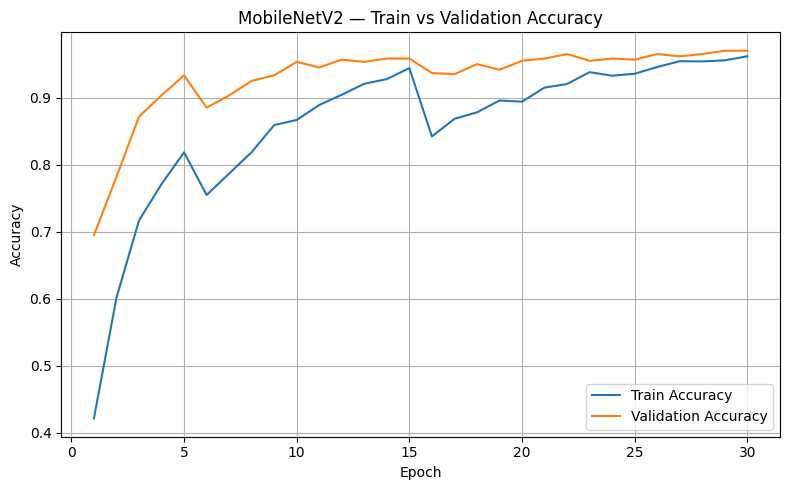

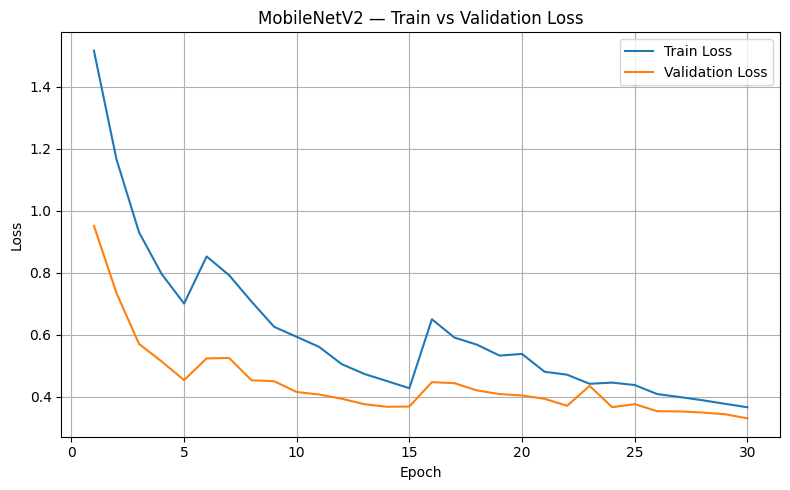

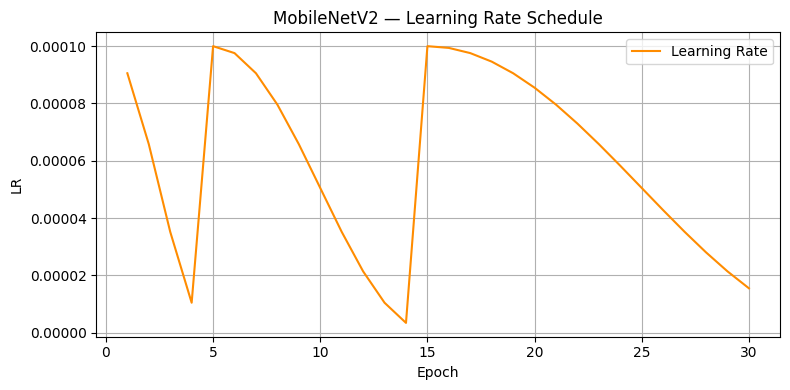


Final Testing on Test Set Only


Final Testing: 100%|██████████| 150/150 [02:02<00:00,  1.23it/s]



Final Test Classification Report:
              precision    recall  f1-score   support

       anger     0.7059    0.8400    0.7671       100
        fear     0.8205    0.9600    0.8848       100
         joy     0.8421    0.9600    0.8972       100
     natural     0.8776    0.8600    0.8687       100
     sadness     0.6977    0.3000    0.4196       100
    surprise     0.7248    0.7900    0.7560       100

    accuracy                         0.7850       600
   macro avg     0.7781    0.7850    0.7656       600
weighted avg     0.7781    0.7850    0.7656       600



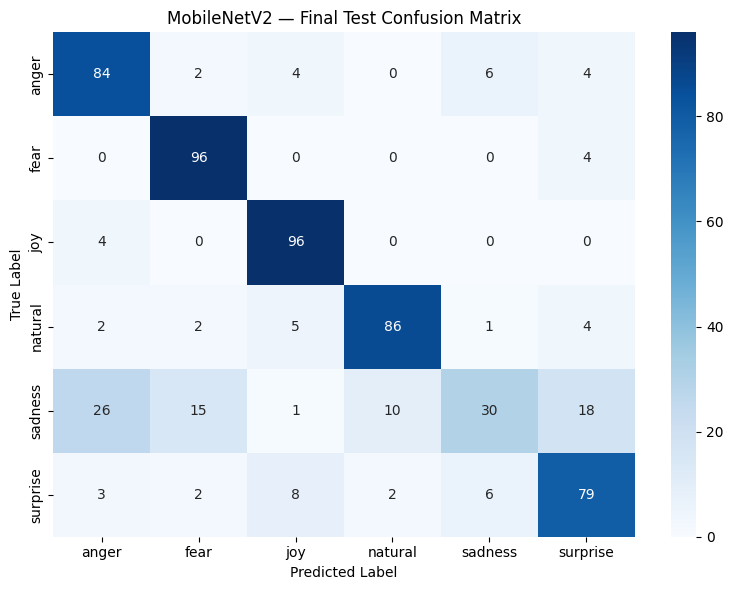


MobileNetV2 Final Result:


,model,batch_size,total_parameters,trainable_parameters,best_val_accuracy,final_test_accuracy,test_macro_precision,test_macro_recall,test_macro_f1,test_weighted_precision,test_weighted_recall,test_weighted_f1
0,mobilenetv2,4,2231558,2231558,0.97,0.785,0.7781,0.785,0.7656,0.7781,0.785,0.7656



Best validation model saved to : /content/drive/MyDrive/Thesis Student/P3 /Group_3_Spring_2025/Update dataset/results/batch_16/mobilenetv2/best_val_model.pth
All files saved inside         : /content/drive/MyDrive/Thesis Student/P3 /Group_3_Spring_2025/Update dataset/results/batch_16/mobilenetv2


In [ ]:
import os
import time
import copy
import torch
import torch.nn as nn
import torch.optim as optim
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from torchvision import datasets, models
from torch.utils.data import DataLoader, ConcatDataset
from tqdm import tqdm
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# ============================================================
# Settings
# ============================================================

RESULTS_DIR_B16 = os.path.join(PROJECT_DIR, "results", "batch_16")
os.makedirs(RESULTS_DIR_B16, exist_ok=True)

# ============================================================
# Datasets — using already defined transform
# ============================================================

train_dataset = datasets.ImageFolder(AUG_TRAIN_DIR, transform=transform)
val_dataset   = datasets.ImageFolder(AUG_VAL_DIR,   transform=transform)
test_dataset  = datasets.ImageFolder(AUG_TEST_DIR,  transform=transform)

if train_dataset.classes != val_dataset.classes:
    raise ValueError("Train and validation class names do not match!")
if train_dataset.classes != test_dataset.classes:
    raise ValueError("Train and test class names do not match!")

class_names = train_dataset.classes
num_classes = len(class_names)

print("Classes          :", class_names)
print("Number of classes:", num_classes)
print("Train images     :", len(train_dataset))
print("Validation images:", len(val_dataset))
print("Test images      :", len(test_dataset))

combined_train_dataset = ConcatDataset([train_dataset, val_dataset])
print("Total training images (train + val):", len(combined_train_dataset))

train_loader = DataLoader(combined_train_dataset, batch_size=BATCH_SIZE, shuffle=True,  num_workers=NUM_WORKERS)
val_loader   = DataLoader(val_dataset,            batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)
test_loader  = DataLoader(test_dataset,           batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)

# ============================================================
# Helper — Parameter Count
# ============================================================

def count_parameters(model):
    total     = sum(p.numel() for p in model.parameters())
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f"  Total parameters    : {total:,}")
    print(f"  Trainable parameters: {trainable:,}")
    return total, trainable

# ============================================================
# Build Model — MobileNetV2
# ============================================================

def build_mobilenetv2(num_classes):
    model = models.mobilenet_v2(weights=models.MobileNet_V2_Weights.IMAGENET1K_V1)
    # Replace the classifier head — MobileNetV2 uses model.classifier[1]
    in_features    = model.classifier[1].in_features
    model.classifier[1] = nn.Linear(in_features, num_classes)
    return model

# ============================================================
# Training Function
# ============================================================

def train_mobilenetv2(epochs=EPOCHS, lr=LR, model_folder_name="mobilenetv2"):
    print("\n" + "=" * 90)
    print("Training MobileNetV2 | Batch Size: 4")
    print("=" * 90)

    model_output_dir = os.path.join(RESULTS_DIR_B16, model_folder_name)
    os.makedirs(model_output_dir, exist_ok=True)

    model = build_mobilenetv2(num_classes).to(device)

    # ── 1. Parameter summary ──────────────────────────────────
    print("\nModel Parameter Summary:")
    total_params, trainable_params = count_parameters(model)

    criterion = nn.CrossEntropyLoss(label_smoothing=0.05)
    optimizer = optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-4)
    scheduler = optim.lr_scheduler.CosineAnnealingWarmRestarts(optimizer, T_0=5, T_mult=2, eta_min=1e-6)

    # ── 2. Track best validation accuracy ────────────────────
    best_val_acc       = 0.0
    best_model_weights = copy.deepcopy(model.state_dict())
    best_val_path      = os.path.join(model_output_dir, "best_val_model.pth")

    history = {
        "train_loss": [], "train_acc": [],
        "val_loss":   [], "val_acc":   [],
        "lr":         []
    }

    for epoch in range(epochs):
        start_time = time.time()
        model.train()
        train_loss_sum, train_correct, train_total = 0.0, 0, 0

        for images, labels in tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs} Training"):
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(images)
            loss    = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            _, predictions  = torch.max(outputs, 1)
            train_loss_sum += loss.item() * images.size(0)
            train_correct  += torch.sum(predictions == labels).item()
            train_total    += labels.size(0)

        train_loss = train_loss_sum / train_total
        train_acc  = train_correct  / train_total

        model.eval()
        val_loss_sum, val_correct, val_total = 0.0, 0, 0

        with torch.no_grad():
            for images, labels in tqdm(val_loader, desc=f"Epoch {epoch+1}/{epochs} Validation"):
                images, labels = images.to(device), labels.to(device)
                outputs        = model(images)
                loss           = criterion(outputs, labels)
                _, predictions = torch.max(outputs, 1)
                val_loss_sum  += loss.item() * images.size(0)
                val_correct   += torch.sum(predictions == labels).item()
                val_total     += labels.size(0)

        val_loss   = val_loss_sum / val_total
        val_acc    = val_correct  / val_total
        scheduler.step()

        current_lr = optimizer.param_groups[0]['lr']
        history["train_loss"].append(train_loss)
        history["train_acc"].append(train_acc)
        history["val_loss"].append(val_loss)
        history["val_acc"].append(val_acc)
        history["lr"].append(current_lr)

        # ── Save best validation weights ──────────────────────
        if val_acc > best_val_acc:
            best_val_acc       = val_acc
            best_model_weights = copy.deepcopy(model.state_dict())
            torch.save(model.state_dict(), best_val_path)
            saved_flag = "  ✓ best val saved"
        else:
            saved_flag = ""

        print(
            f"Epoch {epoch+1}/{epochs} | "
            f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f} | "
            f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f} | "
            f"LR: {current_lr:.8f} | "
            f"Time: {time.time()-start_time:.1f}s"
            f"{saved_flag}"
        )

    model.load_state_dict(best_model_weights)
    pd.DataFrame(history).to_csv(os.path.join(model_output_dir, "training_history.csv"), index=False)

    epochs_range = range(1, epochs + 1)

    # ── 3a. Accuracy curve ────────────────────────────────────
    plt.figure(figsize=(8, 5))
    plt.plot(epochs_range, history["train_acc"], label="Train Accuracy")
    plt.plot(epochs_range, history["val_acc"],   label="Validation Accuracy")
    plt.title("MobileNetV2 — Train vs Validation Accuracy")
    plt.xlabel("Epoch"); plt.ylabel("Accuracy"); plt.legend(); plt.grid(True); plt.tight_layout()
    plt.savefig(os.path.join(model_output_dir, "accuracy_curve.png")); plt.show()

    # ── 3b. Loss curve ────────────────────────────────────────
    plt.figure(figsize=(8, 5))
    plt.plot(epochs_range, history["train_loss"], label="Train Loss")
    plt.plot(epochs_range, history["val_loss"],   label="Validation Loss")
    plt.title("MobileNetV2 — Train vs Validation Loss")
    plt.xlabel("Epoch"); plt.ylabel("Loss"); plt.legend(); plt.grid(True); plt.tight_layout()
    plt.savefig(os.path.join(model_output_dir, "loss_curve.png")); plt.show()

    # ── 3c. Learning-rate curve ───────────────────────────────
    plt.figure(figsize=(8, 4))
    plt.plot(epochs_range, history["lr"], color="darkorange", label="Learning Rate")
    plt.title("MobileNetV2 — Learning Rate Schedule")
    plt.xlabel("Epoch"); plt.ylabel("LR"); plt.legend(); plt.grid(True); plt.tight_layout()
    plt.savefig(os.path.join(model_output_dir, "lr_curve.png")); plt.show()

    print("\n" + "=" * 90)
    print("Final Testing on Test Set Only")
    print("=" * 90)

    model.eval()
    test_y_true, test_y_pred = [], []

    with torch.no_grad():
        for images, labels in tqdm(test_loader, desc="Final Testing"):
            images, labels = images.to(device), labels.to(device)
            outputs        = model(images)
            _, predictions = torch.max(torch.softmax(outputs, dim=1), 1)
            test_y_true.extend(labels.cpu().numpy())
            test_y_pred.extend(predictions.cpu().numpy())

    print("\nFinal Test Classification Report:")
    print(classification_report(test_y_true, test_y_pred, target_names=class_names, digits=4, zero_division=0))

    cm = confusion_matrix(test_y_true, test_y_pred)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt="d", xticklabels=class_names, yticklabels=class_names, cmap="Blues")
    plt.title("MobileNetV2 — Final Test Confusion Matrix")
    plt.xlabel("Predicted Label"); plt.ylabel("True Label"); plt.tight_layout()
    plt.savefig(os.path.join(model_output_dir, "confusion_matrix.png")); plt.show()

    report = classification_report(test_y_true, test_y_pred, target_names=class_names, output_dict=True, zero_division=0)
    pd.DataFrame(report).transpose().to_csv(os.path.join(model_output_dir, "test_classification_report.csv"))
    pd.DataFrame(cm, index=class_names, columns=class_names).to_csv(os.path.join(model_output_dir, "test_confusion_matrix.csv"))

    result = {
        "model":                   model_folder_name,
        "batch_size":              4,
        "total_parameters":        total_params,
        "trainable_parameters":    trainable_params,
        "best_val_accuracy":       round(best_val_acc, 4),
        "final_test_accuracy":     round(accuracy_score(test_y_true, test_y_pred), 4),
        "test_macro_precision":    round(report["macro avg"]["precision"], 4),
        "test_macro_recall":       round(report["macro avg"]["recall"], 4),
        "test_macro_f1":           round(report["macro avg"]["f1-score"], 4),
        "test_weighted_precision": round(report["weighted avg"]["precision"], 4),
        "test_weighted_recall":    round(report["weighted avg"]["recall"], 4),
        "test_weighted_f1":        round(report["weighted avg"]["f1-score"], 4)
    }

    result_df = pd.DataFrame([result])
    result_df.to_csv(os.path.join(model_output_dir, "mobilenetv2_result_summary.csv"), index=False)
    print("\nMobileNetV2 Final Result:"); display(result_df)
    print(f"\nBest validation model saved to : {best_val_path}")
    print("All files saved inside         :", model_output_dir)
    return result, model

mobilenetv2_result, mobilenetv2_model = train_mobilenetv2(
    epochs=EPOCHS, lr=LR, model_folder_name="mobilenetv2"
)

#DenseNet-121 = 0.8083

Classes          : ['anger', 'fear', 'joy', 'natural', 'sadness', 'surprise']
Number of classes: 6
Train images     : 2400
Validation images: 600
Test images      : 600
Total training images (train + val): 3000

Training DenseNet-121 | Batch Size: 4
Downloading: "https://download.pytorch.org/models/densenet121-a639ec97.pth" to /root/.cache/torch/hub/checkpoints/densenet121-a639ec97.pth


100%|██████████| 30.8M/30.8M [00:00<00:00, 238MB/s]



Model Parameter Summary:
  Total parameters    : 6,960,006
  Trainable parameters: 6,960,006


Epoch 1/30 Validation: 100%|██████████| 150/150 [00:03<00:00, 44.19it/s]


Epoch 1/30 | Train Loss: 1.4546 | Train Acc: 0.4597 | Val Loss: 0.8503 | Val Acc: 0.7467 | LR: 0.00009055 | Time: 1168.5s  ✓ best val saved


...

Epoch 28/30 | Train Loss: 0.3308 | Train Acc: 0.9700 | Val Loss: 0.3062 | Val Acc: 0.9867 | LR: 0.00002803 | Time: 53.5s


Epoch 29/30 Validation: 100%|██████████| 150/150 [00:03<00:00, 42.05it/s]


Epoch 29/30 | Train Loss: 0.3182 | Train Acc: 0.9777 | Val Loss: 0.2921 | Val Acc: 0.9867 | LR: 0.00002140 | Time: 53.4s


Epoch 30/30 Validation: 100%|██████████| 150/150 [00:03<00:00, 42.35it/s]


Epoch 30/30 | Train Loss: 0.3148 | Train Acc: 0.9787 | Val Loss: 0.2912 | Val Acc: 0.9900 | LR: 0.00001550 | Time: 54.2s  ✓ best val saved


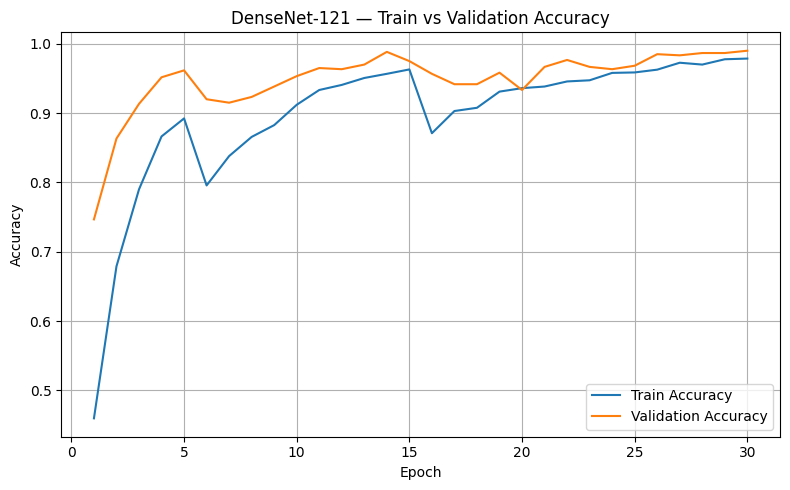

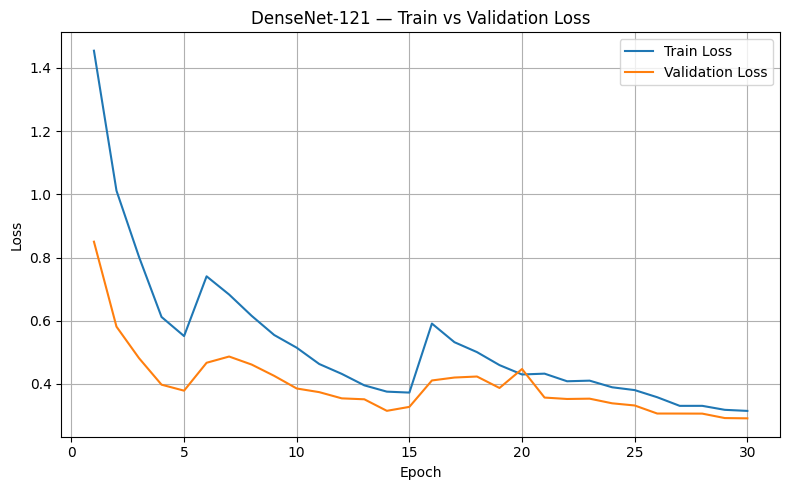

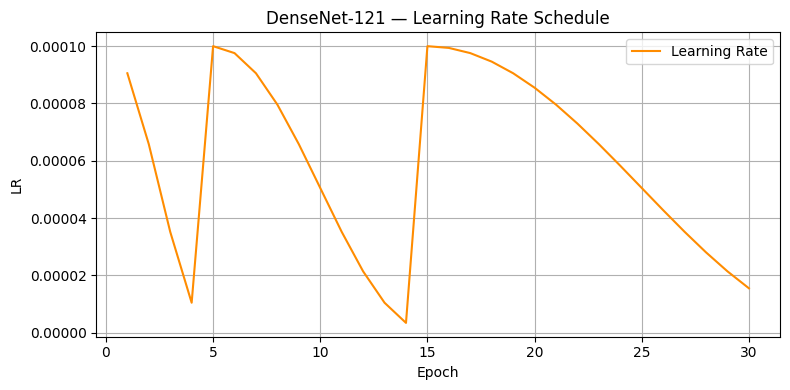


Final Testing on Test Set Only


Final Testing: 100%|██████████| 150/150 [03:59<00:00,  1.59s/it]



Final Test Classification Report:
              precision    recall  f1-score   support

       anger     0.6967    0.8500    0.7658       100
        fear     0.8125    0.9100    0.8585       100
         joy     0.9314    0.9500    0.9406       100
     natural     0.8198    0.9100    0.8626       100
     sadness     0.7170    0.3800    0.4967       100
    surprise     0.8500    0.8500    0.8500       100

    accuracy                         0.8083       600
   macro avg     0.8046    0.8083    0.7957       600
weighted avg     0.8046    0.8083    0.7957       600



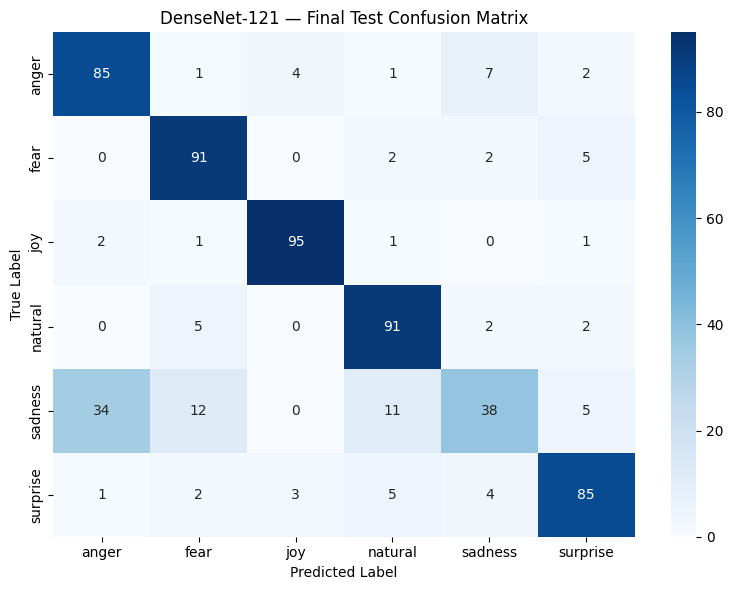


DenseNet-121 Final Result:


,model,batch_size,total_parameters,trainable_parameters,best_val_accuracy,final_test_accuracy,test_macro_precision,test_macro_recall,test_macro_f1,test_weighted_precision,test_weighted_recall,test_weighted_f1
0,densenet121,4,6960006,6960006,0.99,0.8083,0.8046,0.8083,0.7957,0.8046,0.8083,0.7957



Best validation model saved to : /content/drive/MyDrive/Thesis Student/P3 /Group_3_Spring_2025/Update dataset/results/batch_4/densenet121/best_val_model.pth
All files saved inside         : /content/drive/MyDrive/Thesis Student/P3 /Group_3_Spring_2025/Update dataset/results/batch_4/densenet121


In [ ]:
import os
import time
import copy
import torch
import torch.nn as nn
import torch.optim as optim
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from torchvision import datasets, models
from torch.utils.data import DataLoader, ConcatDataset
from tqdm import tqdm
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# ============================================================
# Settings
# ============================================================

RESULTS_DIR_B16 = os.path.join(PROJECT_DIR, "results", "batch_4")
os.makedirs(RESULTS_DIR_B16, exist_ok=True)

# ============================================================
# Datasets — using already defined transform
# ============================================================

train_dataset = datasets.ImageFolder(AUG_TRAIN_DIR, transform=transform)
val_dataset   = datasets.ImageFolder(AUG_VAL_DIR,   transform=transform)
test_dataset  = datasets.ImageFolder(AUG_TEST_DIR,  transform=transform)

if train_dataset.classes != val_dataset.classes:
    raise ValueError("Train and validation class names do not match!")
if train_dataset.classes != test_dataset.classes:
    raise ValueError("Train and test class names do not match!")

class_names = train_dataset.classes
num_classes = len(class_names)

print("Classes          :", class_names)
print("Number of classes:", num_classes)
print("Train images     :", len(train_dataset))
print("Validation images:", len(val_dataset))
print("Test images      :", len(test_dataset))

combined_train_dataset = ConcatDataset([train_dataset, val_dataset])
print("Total training images (train + val):", len(combined_train_dataset))

train_loader = DataLoader(combined_train_dataset, batch_size=BATCH_SIZE, shuffle=True,  num_workers=NUM_WORKERS)
val_loader   = DataLoader(val_dataset,            batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)
test_loader  = DataLoader(test_dataset,           batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)

# ============================================================
# Helper — Parameter Count
# ============================================================

def count_parameters(model):
    total     = sum(p.numel() for p in model.parameters())
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f"  Total parameters    : {total:,}")
    print(f"  Trainable parameters: {trainable:,}")
    return total, trainable

# ============================================================
# Build Model — DenseNet-121
# ============================================================

def build_densenet121(num_classes):
    model = models.densenet121(weights=models.DenseNet121_Weights.IMAGENET1K_V1)
    # DenseNet uses model.classifier (a single Linear layer)
    in_features      = model.classifier.in_features
    model.classifier = nn.Linear(in_features, num_classes)
    return model

# ============================================================
# Training Function
# ============================================================

def train_densenet121(epochs=EPOCHS, lr=LR, model_folder_name="densenet121"):
    print("\n" + "=" * 90)
    print("Training DenseNet-121 | Batch Size: 4")
    print("=" * 90)

    model_output_dir = os.path.join(RESULTS_DIR_B16, model_folder_name)
    os.makedirs(model_output_dir, exist_ok=True)

    model = build_densenet121(num_classes).to(device)

    # ── 1. Parameter summary ──────────────────────────────────
    print("\nModel Parameter Summary:")
    total_params, trainable_params = count_parameters(model)

    criterion = nn.CrossEntropyLoss(label_smoothing=0.05)
    optimizer = optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-4)
    scheduler = optim.lr_scheduler.CosineAnnealingWarmRestarts(optimizer, T_0=5, T_mult=2, eta_min=1e-6)

    # ── 2. Track best validation accuracy ────────────────────
    best_val_acc       = 0.0
    best_model_weights = copy.deepcopy(model.state_dict())
    best_val_path      = os.path.join(model_output_dir, "best_val_model.pth")

    history = {
        "train_loss": [], "train_acc": [],
        "val_loss":   [], "val_acc":   [],
        "lr":         []
    }

    for epoch in range(epochs):
        start_time = time.time()
        model.train()
        train_loss_sum, train_correct, train_total = 0.0, 0, 0

        for images, labels in tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs} Training"):
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(images)
            loss    = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            _, predictions  = torch.max(outputs, 1)
            train_loss_sum += loss.item() * images.size(0)
            train_correct  += torch.sum(predictions == labels).item()
            train_total    += labels.size(0)

        train_loss = train_loss_sum / train_total
        train_acc  = train_correct  / train_total

        model.eval()
        val_loss_sum, val_correct, val_total = 0.0, 0, 0

        with torch.no_grad():
            for images, labels in tqdm(val_loader, desc=f"Epoch {epoch+1}/{epochs} Validation"):
                images, labels = images.to(device), labels.to(device)
                outputs        = model(images)
                loss           = criterion(outputs, labels)
                _, predictions = torch.max(outputs, 1)
                val_loss_sum  += loss.item() * images.size(0)
                val_correct   += torch.sum(predictions == labels).item()
                val_total     += labels.size(0)

        val_loss   = val_loss_sum / val_total
        val_acc    = val_correct  / val_total
        scheduler.step()

        current_lr = optimizer.param_groups[0]['lr']
        history["train_loss"].append(train_loss)
        history["train_acc"].append(train_acc)
        history["val_loss"].append(val_loss)
        history["val_acc"].append(val_acc)
        history["lr"].append(current_lr)

        # ── Save best validation weights ──────────────────────
        if val_acc > best_val_acc:
            best_val_acc       = val_acc
            best_model_weights = copy.deepcopy(model.state_dict())
            torch.save(model.state_dict(), best_val_path)
            saved_flag = "  ✓ best val saved"
        else:
            saved_flag = ""

        print(
            f"Epoch {epoch+1}/{epochs} | "
            f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f} | "
            f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f} | "
            f"LR: {current_lr:.8f} | "
            f"Time: {time.time()-start_time:.1f}s"
            f"{saved_flag}"
        )

    model.load_state_dict(best_model_weights)
    pd.DataFrame(history).to_csv(os.path.join(model_output_dir, "training_history.csv"), index=False)

    epochs_range = range(1, epochs + 1)

    # ── 3a. Accuracy curve ────────────────────────────────────
    plt.figure(figsize=(8, 5))
    plt.plot(epochs_range, history["train_acc"], label="Train Accuracy")
    plt.plot(epochs_range, history["val_acc"],   label="Validation Accuracy")
    plt.title("DenseNet-121 — Train vs Validation Accuracy")
    plt.xlabel("Epoch"); plt.ylabel("Accuracy"); plt.legend(); plt.grid(True); plt.tight_layout()
    plt.savefig(os.path.join(model_output_dir, "accuracy_curve.png")); plt.show()

    # ── 3b. Loss curve ────────────────────────────────────────
    plt.figure(figsize=(8, 5))
    plt.plot(epochs_range, history["train_loss"], label="Train Loss")
    plt.plot(epochs_range, history["val_loss"],   label="Validation Loss")
    plt.title("DenseNet-121 — Train vs Validation Loss")
    plt.xlabel("Epoch"); plt.ylabel("Loss"); plt.legend(); plt.grid(True); plt.tight_layout()
    plt.savefig(os.path.join(model_output_dir, "loss_curve.png")); plt.show()

    # ── 3c. Learning-rate curve ───────────────────────────────
    plt.figure(figsize=(8, 4))
    plt.plot(epochs_range, history["lr"], color="darkorange", label="Learning Rate")
    plt.title("DenseNet-121 — Learning Rate Schedule")
    plt.xlabel("Epoch"); plt.ylabel("LR"); plt.legend(); plt.grid(True); plt.tight_layout()
    plt.savefig(os.path.join(model_output_dir, "lr_curve.png")); plt.show()

    print("\n" + "=" * 90)
    print("Final Testing on Test Set Only")
    print("=" * 90)

    model.eval()
    test_y_true, test_y_pred = [], []

    with torch.no_grad():
        for images, labels in tqdm(test_loader, desc="Final Testing"):
            images, labels = images.to(device), labels.to(device)
            outputs        = model(images)
            _, predictions = torch.max(torch.softmax(outputs, dim=1), 1)
            test_y_true.extend(labels.cpu().numpy())
            test_y_pred.extend(predictions.cpu().numpy())

    print("\nFinal Test Classification Report:")
    print(classification_report(test_y_true, test_y_pred, target_names=class_names, digits=4, zero_division=0))

    cm = confusion_matrix(test_y_true, test_y_pred)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt="d", xticklabels=class_names, yticklabels=class_names, cmap="Blues")
    plt.title("DenseNet-121 — Final Test Confusion Matrix")
    plt.xlabel("Predicted Label"); plt.ylabel("True Label"); plt.tight_layout()
    plt.savefig(os.path.join(model_output_dir, "confusion_matrix.png")); plt.show()

    report = classification_report(test_y_true, test_y_pred, target_names=class_names, output_dict=True, zero_division=0)
    pd.DataFrame(report).transpose().to_csv(os.path.join(model_output_dir, "test_classification_report.csv"))
    pd.DataFrame(cm, index=class_names, columns=class_names).to_csv(os.path.join(model_output_dir, "test_confusion_matrix.csv"))

    result = {
        "model":                   model_folder_name,
        "batch_size":              4,
        "total_parameters":        total_params,
        "trainable_parameters":    trainable_params,
        "best_val_accuracy":       round(best_val_acc, 4),
        "final_test_accuracy":     round(accuracy_score(test_y_true, test_y_pred), 4),
        "test_macro_precision":    round(report["macro avg"]["precision"], 4),
        "test_macro_recall":       round(report["macro avg"]["recall"], 4),
        "test_macro_f1":           round(report["macro avg"]["f1-score"], 4),
        "test_weighted_precision": round(report["weighted avg"]["precision"], 4),
        "test_weighted_recall":    round(report["weighted avg"]["recall"], 4),
        "test_weighted_f1":        round(report["weighted avg"]["f1-score"], 4)
    }

    result_df = pd.DataFrame([result])
    result_df.to_csv(os.path.join(model_output_dir, "densenet121_result_summary.csv"), index=False)
    print("\nDenseNet-121 Final Result:"); display(result_df)
    print(f"\nBest validation model saved to : {best_val_path}")
    print("All files saved inside         :", model_output_dir)
    return result, model

# ============================================================
# Run
# ============================================================

densenet121_result, densenet121_model = train_densenet121(
    epochs=EPOCHS, lr=LR, model_folder_name="densenet121"
)

#hybrid = .8250

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model.safetensors:   0%|          | 0.00/124M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/21.4M [00:00<?, ?B/s]


MODEL PARAMETER SUMMARY
Total Params : 37,107,594
Trainable    : 37,107,594



Epoch 1/30: 100%|██████████| 750/750 [02:40<00:00,  4.67it/s]


...


Epoch 28/30
----------------------------------------
Train Loss : 0.4766
Train Acc  : 0.9817
Val Loss   : 0.4630
Val Acc    : 0.9833
Precision  : 0.9837
Recall     : 0.9833
F1 Score   : 0.9833
Time       : 147.38 sec


Epoch 29/30: 100%|██████████| 750/750 [02:19<00:00,  5.38it/s]



Epoch 29/30
----------------------------------------
Train Loss : 0.4837
Train Acc  : 0.9790
Val Loss   : 0.4717
Val Acc    : 0.9817
Precision  : 0.9817
Recall     : 0.9817
F1 Score   : 0.9817
Time       : 147.97 sec


Epoch 30/30: 100%|██████████| 750/750 [02:19<00:00,  5.38it/s]



Epoch 30/30
----------------------------------------
Train Loss : 0.4811
Train Acc  : 0.9803
Val Loss   : 0.4566
Val Acc    : 0.9833
Precision  : 0.9835
Recall     : 0.9833
F1 Score   : 0.9833
Time       : 147.97 sec

TEST RESULTS
Accuracy  : 0.8250
Precision : 0.8209
Recall    : 0.8250
F1 Score  : 0.8192

Classification Report:

              precision    recall  f1-score   support

       anger     0.7182    0.7900    0.7524       100
        fear     0.8692    0.9300    0.8986       100
         joy     0.9307    0.9400    0.9353       100
     natural     0.8482    0.9500    0.8962       100
     sadness     0.7222    0.5200    0.6047       100
    surprise     0.8367    0.8200    0.8283       100

    accuracy                         0.8250       600
   macro avg     0.8209    0.8250    0.8192       600
weighted avg     0.8209    0.8250    0.8192       600



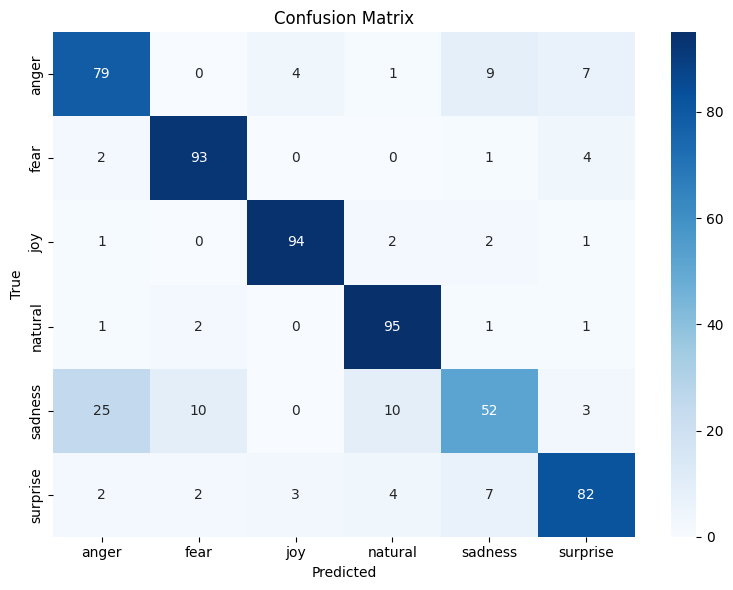

In [ ]:
import os
import gc
import time
import copy
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import timm
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from torchvision import datasets
from torch.utils.data import DataLoader, ConcatDataset
from tqdm import tqdm
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.utils.class_weight import compute_class_weight

# ============================================================
# Memory Optimization
# ============================================================

os.environ["PYTORCH_ALLOC_CONF"] = "expandable_segments:True"
torch.cuda.empty_cache()
gc.collect()

# ============================================================
# Dataset
# ============================================================

train_dataset = datasets.ImageFolder(AUG_TRAIN_DIR, transform=transform)
val_dataset   = datasets.ImageFolder(AUG_VAL_DIR, transform=transform)
test_dataset  = datasets.ImageFolder(AUG_TEST_DIR, transform=transform)

class_names = train_dataset.classes
num_classes = len(class_names)

combined_train_dataset = ConcatDataset([train_dataset, val_dataset])

train_loader = DataLoader(
    combined_train_dataset,
    batch_size=4,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=4,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=4,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True
)

# ============================================================
# Class Weights
# ============================================================

_train_labels = [label for _, label in train_dataset.samples]

_class_weights_np = compute_class_weight(
    class_weight="balanced",
    classes=np.arange(num_classes),
    y=_train_labels
)

class_weights_tensor = torch.tensor(
    _class_weights_np,
    dtype=torch.float
)
# ============================================================
# ASD-MAXFUSIONNET
# Hybrid MaxViT + EfficientNetB0
# Autism Child Emotion Detection
# ============================================================

import os
import copy
import time
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from tqdm import tqdm

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F

import timm

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    f1_score,
    precision_score,
    recall_score
)

# ============================================================
# CONFIG
# ============================================================

RESULTS_DIR = "./results"

os.makedirs(RESULTS_DIR, exist_ok=True)

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

NUM_CLASSES = 6

CLASS_NAMES = [
    "anger",
    "fear",
    "joy",
    "natural",
    "sadness",
    "surprise"
]

IMAGE_SIZE = 224

# ============================================================
# SE BLOCK
# ============================================================

class SEBlock(nn.Module):

    def __init__(
        self,
        channels,
        reduction=16
    ):

        super().__init__()

        hidden = max(channels // reduction, 8)

        self.pool = nn.AdaptiveAvgPool2d(1)

        self.fc = nn.Sequential(

            nn.Linear(channels, hidden),

            nn.ReLU(inplace=True),

            nn.Linear(hidden, channels),

            nn.Sigmoid()
        )

    def forward(self, x):

        b, c = x.shape

        y = self.fc(x)

        return x * y

# ============================================================
# ATTENTION FUSION
# ============================================================

class AttentionFusion(nn.Module):

    def __init__(self, dim):

        super().__init__()

        self.attn = nn.Sequential(

            nn.Linear(dim * 2, dim),

            nn.GELU(),

            nn.Dropout(0.2),

            nn.Linear(dim, dim * 2),

            nn.Sigmoid()
        )

    def forward(self, x1, x2):

        fused = torch.cat(
            [x1, x2],
            dim=1
        )

        weights = self.attn(fused)

        w1, w2 = torch.chunk(
            weights,
            2,
            dim=1
        )

        x1 = x1 * w1
        x2 = x2 * w2

        return torch.cat(
            [x1, x2],
            dim=1
        )

# ============================================================
# FOCAL LOSS
# ============================================================

class FocalLoss(nn.Module):

    def __init__(
        self,
        gamma=2.0,
        reduction="mean"
    ):

        super().__init__()

        self.gamma = gamma

        self.reduction = reduction

    def forward(
        self,
        inputs,
        targets
    ):

        ce_loss = F.cross_entropy(
            inputs,
            targets,
            reduction="none"
        )

        pt = torch.exp(-ce_loss)

        focal_loss = (
            (1 - pt) ** self.gamma
        ) * ce_loss

        if self.reduction == "mean":
            return focal_loss.mean()

        return focal_loss.sum()

# ============================================================
# ASD-MAXFUSIONNET
# ============================================================

class ASDMaxFusionNet(nn.Module):

    def __init__(
        self,
        num_classes=6,
        pretrained=True
    ):

        super().__init__()

        # ====================================================
        # MAXVIT BRANCH
        # ====================================================

        self.maxvit = timm.create_model(
            'maxvit_tiny_tf_224',
            pretrained=pretrained,
            num_classes=0,
            global_pool='avg'
        )

        maxvit_dim = self.maxvit.num_features

        # ====================================================
        # EFFICIENTNET BRANCH
        # ====================================================

        self.efficientnet = timm.create_model(
            'efficientnet_b0',
            pretrained=pretrained,
            num_classes=0,
            global_pool='avg'
        )

        eff_dim = self.efficientnet.num_features

        # ====================================================
        # FEATURE REFINEMENT
        # ====================================================

        self.maxvit_branch = nn.Sequential(

            nn.Linear(maxvit_dim, 512),

            nn.LayerNorm(512),

            nn.GELU(),

            nn.Dropout(0.3)
        )

        self.efficient_branch = nn.Sequential(

            nn.Linear(eff_dim, 512),

            nn.LayerNorm(512),

            nn.GELU(),

            nn.Dropout(0.3)
        )

        # ====================================================
        # SE ATTENTION
        # ====================================================

        self.maxvit_se = SEBlock(512)

        self.efficient_se = SEBlock(512)

        # ====================================================
        # ATTENTION FUSION
        # ====================================================

        self.fusion = AttentionFusion(512)

        # ====================================================
        # CLASSIFIER
        # ====================================================

        self.classifier = nn.Sequential(

            nn.Linear(1024, 512),

            nn.LayerNorm(512),

            nn.GELU(),

            nn.Dropout(0.4),

            nn.Linear(512, 256),

            nn.LayerNorm(256),

            nn.GELU(),

            nn.Dropout(0.3),

            nn.Linear(256, num_classes)
        )

    def forward(self, x):

        # ====================================================
        # MAXVIT FEATURES
        # ====================================================

        maxvit_feat = self.maxvit(x)

        maxvit_feat = self.maxvit_branch(
            maxvit_feat
        )

        maxvit_feat = self.maxvit_se(
            maxvit_feat
        )

        # ====================================================
        # EFFICIENTNET FEATURES
        # ====================================================

        eff_feat = self.efficientnet(x)

        eff_feat = self.efficient_branch(
            eff_feat
        )

        eff_feat = self.efficient_se(
            eff_feat
        )

        # ====================================================
        # FUSION
        # ====================================================

        fused = self.fusion(
            maxvit_feat,
            eff_feat
        )

        # ====================================================
        # CLASSIFICATION
        # ====================================================

        out = self.classifier(fused)

        return out

# ============================================================
# PARAMETER SUMMARY
# ============================================================

def print_parameter_summary(model):

    total = sum(
        p.numel()
        for p in model.parameters()
    )

    trainable = sum(
        p.numel()
        for p in model.parameters()
        if p.requires_grad
    )

    print("\n==============================")

    print("MODEL PARAMETER SUMMARY")

    print("==============================")

    print(f"Total Params : {total:,}")

    print(f"Trainable    : {trainable:,}")

    print("==============================\n")

# ============================================================
# TRAIN FUNCTION
# ============================================================

def train_model(
    train_loader,
    val_loader,
    epochs=30,
    lr=1e-4
):

    model = ASDMaxFusionNet(
        num_classes=NUM_CLASSES
    ).to(device)

    print_parameter_summary(model)

    # criterion = FocalLoss()
    criterion = nn.CrossEntropyLoss(label_smoothing=0.1)

    optimizer = optim.AdamW(
        model.parameters(),
        lr=lr,
        weight_decay=1e-4
    )

    scheduler = optim.lr_scheduler.CosineAnnealingLR(
        optimizer,
        T_max=epochs
    )

    scaler = torch.amp.GradScaler("cuda")

    best_val_acc = 0.0

    best_weights = copy.deepcopy(
        model.state_dict()
    )

    history = {

        "train_acc": [],
        "val_acc": [],

        "train_loss": [],
        "val_loss": []
    }

    # ========================================================
    # TRAIN LOOP
    # ========================================================

    for epoch in range(epochs):

        start = time.time()

        # ====================================================
        # TRAIN
        # ====================================================

        model.train()

        train_loss = 0.0

        train_correct = 0

        train_total = 0

        for images, labels in tqdm(
            train_loader,
            desc=f"Epoch {epoch+1}/{epochs}"
        ):

            images = images.to(device)

            labels = labels.to(device)

            optimizer.zero_grad()

            with torch.amp.autocast("cuda"):

                outputs = model(images)

                loss = criterion(
                    outputs,
                    labels
                )

            scaler.scale(loss).backward()

            torch.nn.utils.clip_grad_norm_(
                model.parameters(),
                max_norm=1.0
            )

            scaler.step(optimizer)

            scaler.update()

            _, preds = torch.max(
                outputs,
                1
            )

            train_loss += (
                loss.item() * images.size(0)
            )

            train_correct += torch.sum(
                preds == labels
            ).item()

            train_total += labels.size(0)

        train_epoch_loss = (
            train_loss / train_total
        )

        train_epoch_acc = (
            train_correct / train_total
        )

        # ====================================================
        # VALIDATION
        # ====================================================

        model.eval()

        val_loss = 0.0

        val_correct = 0

        val_total = 0

        all_preds = []

        all_labels = []

        with torch.no_grad():

            for images, labels in val_loader:

                images = images.to(device)

                labels = labels.to(device)

                with torch.amp.autocast("cuda"):

                    outputs = model(images)

                    loss = criterion(
                        outputs,
                        labels
                    )

                _, preds = torch.max(
                    outputs,
                    1
                )

                val_loss += (
                    loss.item() * images.size(0)
                )

                val_correct += torch.sum(
                    preds == labels
                ).item()

                val_total += labels.size(0)

                all_preds.extend(
                    preds.cpu().numpy()
                )

                all_labels.extend(
                    labels.cpu().numpy()
                )

        val_epoch_loss = (
            val_loss / val_total
        )

        val_epoch_acc = (
            val_correct / val_total
        )

        scheduler.step()

        # ====================================================
        # SAVE HISTORY
        # ====================================================

        history["train_acc"].append(
            train_epoch_acc
        )

        history["val_acc"].append(
            val_epoch_acc
        )

        history["train_loss"].append(
            train_epoch_loss
        )

        history["val_loss"].append(
            val_epoch_loss
        )

        # ====================================================
        # SAVE BEST MODEL
        # ====================================================

        if val_epoch_acc > best_val_acc:

            best_val_acc = val_epoch_acc

            best_weights = copy.deepcopy(
                model.state_dict()
            )

            torch.save(

                model.state_dict(),

                os.path.join(
                    RESULTS_DIR,
                    "best_asd_maxfusionnet.pth"
                )
            )

        # ====================================================
        # METRICS
        # ====================================================

        precision = precision_score(
            all_labels,
            all_preds,
            average='weighted'
        )

        recall = recall_score(
            all_labels,
            all_preds,
            average='weighted'
        )

        f1 = f1_score(
            all_labels,
            all_preds,
            average='weighted'
        )

        end = time.time()

        print("\n========================================")

        print(f"Epoch {epoch+1}/{epochs}")

        print("----------------------------------------")

        print(
            f"Train Loss : {train_epoch_loss:.4f}"
        )

        print(
            f"Train Acc  : {train_epoch_acc:.4f}"
        )

        print(
            f"Val Loss   : {val_epoch_loss:.4f}"
        )

        print(
            f"Val Acc    : {val_epoch_acc:.4f}"
        )

        print(
            f"Precision  : {precision:.4f}"
        )

        print(
            f"Recall     : {recall:.4f}"
        )

        print(
            f"F1 Score   : {f1:.4f}"
        )

        print(
            f"Time       : {(end-start):.2f} sec"
        )

        print("========================================")

    # ========================================================
    # LOAD BEST MODEL
    # ========================================================

    model.load_state_dict(best_weights)

    return model, history

# ============================================================
# TEST FUNCTION
# ============================================================

def evaluate_model(
    model,
    test_loader
):

    model.eval()

    all_preds = []

    all_labels = []

    with torch.no_grad():

        for images, labels in test_loader:

            images = images.to(device)

            outputs = model(images)

            _, preds = torch.max(
                outputs,
                1
            )

            all_preds.extend(
                preds.cpu().numpy()
            )

            all_labels.extend(
                labels.numpy()
            )

    acc = accuracy_score(
        all_labels,
        all_preds
    )

    precision = precision_score(
        all_labels,
        all_preds,
        average='weighted'
    )

    recall = recall_score(
        all_labels,
        all_preds,
        average='weighted'
    )

    f1 = f1_score(
        all_labels,
        all_preds,
        average='weighted'
    )

    print("\n================================")

    print("TEST RESULTS")

    print("================================")

    print(f"Accuracy  : {acc:.4f}")

    print(f"Precision : {precision:.4f}")

    print(f"Recall    : {recall:.4f}")

    print(f"F1 Score  : {f1:.4f}")

    print("================================")

    # ========================================================
    # CLASSIFICATION REPORT
    # ========================================================

    print("\nClassification Report:\n")

    print(

        classification_report(
            all_labels,
            all_preds,
            target_names=CLASS_NAMES,
             digits=4
        )
    )

    # ========================================================
    # CONFUSION MATRIX
    # ========================================================

    cm = confusion_matrix(
        all_labels,
        all_preds
    )

    plt.figure(figsize=(8, 6))

    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap='Blues',
        xticklabels=CLASS_NAMES,
        yticklabels=CLASS_NAMES
    )

    plt.xlabel("Predicted")

    plt.ylabel("True")

    plt.title("Confusion Matrix")

    plt.tight_layout()

    plt.savefig(

        os.path.join(
            RESULTS_DIR,
            "confusion_matrix.png"
        )
    )

    plt.show()

# ============================================================
# RUN TRAINING
# ============================================================

"""
IMPORTANT:

You must already define:

train_loader
val_loader
test_loader

before running this section.
"""

model, history = train_model(

    train_loader=train_loader,

    val_loader=val_loader,

    epochs=30,

    lr=1e-4
)

# ============================================================
# EVALUATION
# ============================================================

evaluate_model(
    model,
    test_loader
)